In [ ]:
! pip install yfinance
! pip install arch
! pip install statsmodels
! pip install hmmlearn
! pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 8.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

from numpy.linalg import eig
from sklearn.preprocessing import QuantileTransformer

import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA
from arch.unitroot import ADF, KPSS
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import norm, t
from hmmlearn.hmm import CategoricalHMM
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from arch.unitroot import ADF, KPSS
from hmmlearn.hmm import GaussianHMM
import networkx as nx
from pgmpy.estimators import (HillClimbSearch, BIC,BayesianEstimator,ExpertKnowledge,)
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
from pgmpy.estimators import (
    HillClimbSearch,
    PC,
    BIC,
    BDeu,
    BayesianEstimator
)
from pgmpy.models import DiscreteBayesianNetwork

# **Model Two : PCA + Gaussian HMM**

In [ ]:
# raw data
data = pd.read_csv('data_final.csv').set_index('Date')
data.index = pd.to_datetime(data.index)

# to reduce the dimension define - Supply = 	opec_product + nonopec_product and / Demand = 	oecd_consump+ nonoecd_consump
data['supply'] = data['opec_product'] + data['nonopec_product']
data['demand'] = data['oecd_consump'] + data['nonoecd_consump']
data.drop(columns=['opec_product', 'nonopec_product', 'oecd_consump', 'nonoecd_consump'], inplace=True)

# perform stationary check
df = data.copy()
def plots(col):
    adf_c = ADF(df[col].dropna(), trend="c", method="bic")
    adf_ct = ADF(df[col].dropna(), trend="ct", method="bic")
    kpss = KPSS(df[col].dropna(), trend="ct", lags=-1)
    # Return results
    return {
        "Variable": col,
        "ADF(c) Stat": round(adf_c.stat,4),
        "ADF(c) p": round(adf_c.pvalue,4),
        "ADF(ct) Stat": round(adf_ct.stat,4),
        "ADF(ct) p": round(adf_ct.pvalue,4),
        "KPSS Stat": round(kpss.stat,4),
        "KPSS p": round(kpss.pvalue,4),}

# data transformation
# 1. First Difference
first_diff = [ 'IPG21112S', 'A24STI','dgs10','oecd_inds']
for col in first_diff:
    df[col] = df[col].diff()

# 2. Log Difference (Growth Rate) & Log Returns (Financial Prices)
log_diff = ['DX_Y_NYB', 'nasdaq', 'russia_inds', 'us_inds',  'supply', 'demand', 'cl_f',  'india_inds', "china_inds"]
for col in log_diff:
    df[col] = np.log(df[col]).diff()
df = df.dropna()
# stationary result
results_2 = []
for col in df.columns:
    results_2.append(plots(col))

stationarity_df_2 = pd.DataFrame(results_2)
display(stationarity_df_2)

,Variable,ADF(c) Stat,ADF(c) p,ADF(ct) Stat,ADF(ct) p,KPSS Stat,KPSS p
0,Temp_mean_anom,-1.7780,0.3915,-5.7286,0.0,0.0976,0.1723
1,oecd_inds,-7.4077,0.0000,-7.3950,0.0,0.0225,0.9586
2,russia_inds,-8.2757,0.0000,-8.2888,0.0,0.0451,0.6442
3,us_inds,-13.5213,0.0000,-13.5316,0.0,0.0328,0.8321
4,india_inds,-14.1971,0.0000,-14.2072,0.0,0.0408,0.7093
5,china_inds,-14.8976,0.0000,-14.8762,0.0,0.0378,0.7560
6,world_inv,-5.4172,0.0000,-6.0960,0.0,0.1108,0.1235
7,geo_risk,-7.3333,0.0000,-7.3220,0.0,0.1098,0.1268
8,IPG21112S,-21.0137,0.0000,-21.2149,0.0,0.0577,0.4748
9,A24STI,-12.1619,0.0000,-12.1547,0.0,0.0539,0.5214


In [ ]:
def PCA_func(column_name, columns , train_scaled_df, valid_scaled_df, n_components):

  sub_train_scaled = train_scaled_df.loc[:,columns]
  sub_valid_scaled = valid_scaled_df.loc[:,columns]
  # Fit PCA
  pca = PCA(n_components=n_components)
  X_pca = pca.fit_transform(sub_train_scaled)
  x_pca_df = pd.DataFrame(X_pca, columns=[f"PC{column_name}_{i+1}" for i in range(n_components)], index = sub_train_scaled.index )
  v_pca = pca.transform(sub_valid_scaled)
  v_pca_df = pd.DataFrame(v_pca, columns=[f"PC{column_name}_{i+1}" for i in range(n_components)], index = sub_valid_scaled.index )

  explained = pca.explained_variance_ratio_
  cumulative = np.cumsum(explained)
  # Loadings
  loadings = pd.DataFrame(pca.components_.T,index=sub_train_scaled.columns,columns=[f"PC{i+1}" for i in range(len(explained))])
  return x_pca_df, v_pca_df,  loadings

In [ ]:
def pre_processing_pca(train, valid):

  scaler =  QuantileTransformer(n_quantiles=min(100, len(train)),output_distribution='normal',random_state=42)
  # scale train
  train_scaled = scaler.fit_transform(train)
  train_scaled_df = pd.DataFrame(train_scaled, index =train.index, columns=train.columns)
  # scale valid
  valid_scaled = scaler.transform(valid)
  valid_scaled_df = pd.DataFrame(valid_scaled, index =valid.index, columns=valid.columns)

  columns_industrial = ['oecd_inds', 'us_inds', 'IPG21112S', 'A24STI', 'CAPUTLG211S']
  x_pca_df_ind, v_pca_df_ind, loadings_industrial = PCA_func('industrial',columns_industrial , train_scaled_df, valid_scaled_df, 2)

  columns_developing = ['china_inds', 'russia_inds', 'india_inds']
  x_pca_df_developing, v_pca_df_developing, loadings_developing = PCA_func('Developing',columns_developing , train_scaled_df, valid_scaled_df, 2)

  columns_market = ['vix', 'DX_Y_NYB', 'nasdaq', 'dgs10']
  x_pca_df_market, v_pca_df_market, loadings_market = PCA_func('Market',columns_market , train_scaled_df, valid_scaled_df, 2)

  train_processed = pd.concat([train_scaled_df, x_pca_df_ind, x_pca_df_developing, x_pca_df_market], axis = 1)
  valid_processed = pd.concat([valid_scaled_df, v_pca_df_ind, v_pca_df_developing, v_pca_df_market], axis = 1)

  for i in [columns_industrial, columns_developing, columns_market]:
    train_processed = train_processed.drop(columns = i)
    valid_processed = valid_processed.drop(columns = i)

  return train_processed, valid_processed, loadings_industrial, loadings_developing, loadings_market

In [ ]:
def filter_gaussian_hmm(model, X, alpha_prev=None):

    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    n_states = model.n_components
    # Calculate Gaussian emission probabilities
    emission_probs = np.zeros((len(X), n_states))
    for k in range(n_states):
        emission_probs[:, k] = multivariate_normal.pdf(X, mean=model.means_[k], cov=model.covars_[k],allow_singular=True)
    # First observation
    if alpha_prev is None:
        alpha = model.startprob_.copy()
        alpha *= emission_probs[0]
        alpha /= alpha.sum()
        states = [np.argmax(alpha)]
        probabilities = [alpha.copy()]
        start = 1
    else:
        alpha = alpha_prev.copy()
        states = []
        probabilities = []
        start = 0
    # Forward filtering
    for i in range(start, len(X)):
        # Predict next state
        alpha = alpha @ model.transmat_
        # Update using current observation
        alpha *= emission_probs[i]
        # Normalize
        alpha /= alpha.sum()
        # Most probable current state
        state = np.argmax(alpha)
        states.append(state)
        probabilities.append(alpha.copy())
    return np.array(states), np.array(probabilities), alpha

In [ ]:
from scipy.stats import multivariate_normal
# Rolling Window Parameters
train_size = 12 * 15      # 180 months
valid_size = 12 * 2       # 24 months
test_size  = 12 * 1       # 12 months

window_size = train_size + valid_size + test_size + 3
n_windows = len(df) - window_size + 1

train_data_int = {}
valid_data_int = {}
test_data_int = {}

train_data_cat = {}
valid_data_cat = {}
test_data_cat = {}

loading = {'industrial': {},'developing' : {}, 'market': {}}

# Rolling Window
for i in range(n_windows):
    window = df.iloc[i : i + window_size].copy()
    train = window.iloc[:train_size+1]
    valid = window.iloc[train_size+1 :train_size+1 + valid_size+1]
    test = window.iloc[train_size+1 + valid_size+1 :]

    train_processed, valid_processed, loading['industrial'][i], loading['developing'][i], loading['market'][i] = pre_processing_pca(train, valid)

    regime_train_int = pd.DataFrame(index=train_processed.index)
    regime_valid_int = pd.DataFrame(index=valid_processed.index)

    regime_train_cat = pd.DataFrame(index=train_processed.index)
    regime_valid_cat = pd.DataFrame(index=valid_processed.index)

    # HMM for each variable
    for col in train_processed.columns:

        X_train = train_processed[[col]].values
        X_valid = valid_processed[[col]].values

        model = GaussianHMM(n_components=3,covariance_type='full',n_iter=1000,random_state=42)
        model.fit(X_train)

        # TRAIN
        train_states, train_probs, last_alpha = filter_gaussian_hmm(model, X_train)
        # VALIDATION
        valid_states, valid_probs, last_alpha = filter_gaussian_hmm(model, X_valid, alpha_prev=last_alpha)


        regime_train_int[col] = train_states
        regime_valid_int[col] = valid_states

        temp = pd.DataFrame({"value": train_processed[col],"state": train_states})
        state_mean = temp.groupby("state")["value"].mean()
        high = state_mean.idxmax()
        low = state_mean.idxmin()
        mapping = {}
        for s in state_mean.index:
            if s == high:
                mapping[s] = "High"
            elif s == low:
                mapping[s] = "Low"
            else:
                mapping[s] = "Middle"

        regime_train_cat[col] = regime_train_int[col].map(mapping)
        regime_valid_cat[col] = regime_valid_int[col].map(mapping)

    train_data_int[i] = regime_train_int
    valid_data_int[i] = regime_valid_int

    train_data_cat[i] = regime_train_cat
    valid_data_cat[i] = regime_valid_cat


In [ ]:
def build_bn(train_df, search_class, score_class=None, max_indegree=4,equivalent_sample_size=10):
    forbidden_edges = [("target", col) for col in train_df.columns if col != "target"]
    expert = ExpertKnowledge(forbidden_edges=forbidden_edges)
    search = search_class(train_df)
    if score_class is None:
        dag = search.estimate(return_type="dag",expert_knowledge=expert)
    else:
        dag = search.estimate(scoring_method=score_class(train_df),expert_knowledge=expert, max_indegree=max_indegree)
    model = DiscreteBayesianNetwork(dag.edges())
     # keep every variable
    model.add_nodes_from(train_df.columns)
    # add learned relationships
    model.add_edges_from(dag.edges())
    # pgmpy estimates every Conditional Probability Table (CPT).
    model.fit(train_df)
    return model   #the network structure and CPT


In [ ]:
candidate_models = [{"name":"HC_BIC", "search":HillClimbSearch,"score":BIC},
                    {"name":"HC_BDeu","search":HillClimbSearch,"score":BDeu},
                    {"name":"PC","search":PC,"score":None}]

from pgmpy.inference import VariableElimination
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results = []
all_y_true = []
all_y_pred = []

for w in range(n_windows):

    train = train_data_cat[w].copy()
    valid = valid_data_cat[w].copy()

    # Remove constant variables based on TRAIN
    constant_cols = [c for c in train.columns if train[c].nunique() <= 1]
    train = train.drop(columns=constant_cols)
    valid = valid.drop(columns=constant_cols)

    # Next-month target
    train["target"] = train["cl_f"].shift(-1)
    valid["target"] = valid["cl_f"].shift(-1)

    train.dropna(inplace=True)
    valid.dropna(inplace=True)

    # Find best candidate using VALIDATION
    best_model = None
    best_name = None
    best_f1 = -1

    best_val_accuracy = None
    best_val_f1_macro = None
    best_val_f1_weighted = None
    best_val_f1_micro = None

    best_y_true = None
    best_y_pred = None

    for candidate in candidate_models:


        model = build_bn(train,candidate["search"], candidate["score"], max_indegree=4)
        infer = VariableElimination(model)
        y_true = []
        y_pred = []
        predictors = [c for c in valid.columns if c != "target"]

        # Predict VALIDATION
        for _, row in valid.iterrows():
            evidence = row[predictors].to_dict()
            pred = infer.map_query(variables=["target"], evidence=evidence,show_progress=False)
            y_true.append(row["target"])
            y_pred.append(pred["target"])

        # Validation metrics
        val_acc = accuracy_score(y_true, y_pred)
        val_f1_macro = f1_score(y_true,y_pred,average="macro")
        val_f1_weighted = f1_score(y_true,y_pred, average="weighted")
        val_f1_micro = f1_score( y_true, y_pred, average="micro")

        # Select model using MACRO F1
        if val_f1_macro > best_f1:

            best_f1 = val_f1_macro

            best_model = model
            best_name = candidate["name"]

            best_val_accuracy = val_acc
            best_val_f1_macro = val_f1_macro
            best_val_f1_weighted = val_f1_weighted
            best_val_f1_micro = val_f1_micro

            best_y_true = y_true.copy()
            best_y_pred = y_pred.copy()

    # Store validation predictions of selected model
    all_y_true.append(best_y_true)
    all_y_pred.append(best_y_pred)

    # Train performance of selected model
    infer = VariableElimination(best_model)

    y_true_train = []
    y_pred_train = []

    predictors_train = [c for c in train.columns if c != "target"]
    for _, row in train.iterrows():

        evidence = row[predictors_train].to_dict()
        pred_train = infer.map_query(variables=["target"],evidence=evidence,show_progress=False)
        y_true_train.append(row["target"])
        y_pred_train.append(pred_train["target"])

    train_acc = accuracy_score(y_true_train,y_pred_train)
    train_f1_macro = f1_score(y_true_train,y_pred_train,average="macro")

    train_f1_weighted = f1_score(y_true_train,y_pred_train,average="weighted")
    train_f1_micro = f1_score(y_true_train, y_pred_train,average="micro")

    results.append({"window": w,"best_model": best_name,
        "train_accuracy": train_acc,"train_f1_macro": train_f1_macro,"train_f1_weighted": train_f1_weighted, "train_f1_micro": train_f1_micro,
        "validation_accuracy": best_val_accuracy,"val_f1_macro": best_val_f1_macro,"val_f1_weighted": best_val_f1_weighted,"val_f1_micro": best_val_f1_micro,
        "n_edges": len(best_model.edges()),"edges": list(best_model.edges()),"target_parents": list(best_model.predecessors("target"))})
    print(f"Window {w}: "f"{best_name}, "f"Validation Macro F1 = {best_val_f1_macro:.3f}")


  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Window 0: HC_BIC, Validation Macro F1 = 0.958


  0%|          | 0/1000000 [00:00<?, ?it/s]

...

Window 95: HC_BIC, Validation Macro F1 = 0.917


  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Window 96: HC_BIC, Validation Macro F1 = 1.000


BASELINE MODEL — ROLLING-WINDOW RESULTS


,train_accuracy,validation_accuracy,train_f1_macro,train_f1_weighted,train_f1_micro,val_f1_macro,val_f1_weighted,val_f1_micro
window,,,,,,,,
0,0.961,0.958,0.920,0.961,0.961,0.958,0.958,0.958
1,0.961,0.958,0.920,0.961,0.961,0.958,0.958,0.958
2,0.961,0.875,0.920,0.961,0.961,0.875,0.875,0.875
3,0.983,0.958,0.959,0.983,0.983,0.958,0.958,0.958
4,0.972,0.958,0.951,0.972,0.972,0.958,0.958,0.958



BASELINE MODEL — PERFORMANCE SUMMARY


,Mean,Std. Dev.,Minimum,Maximum
train_accuracy,0.909,0.072,0.711,0.994
validation_accuracy,0.856,0.119,0.542,1.000
train_f1_macro,0.754,0.195,0.295,0.962
train_f1_weighted,0.900,0.087,0.632,0.994
train_f1_micro,0.909,0.072,0.711,0.994
val_f1_macro,0.724,0.213,0.263,1.000
val_f1_weighted,0.844,0.134,0.421,1.000
val_f1_micro,0.856,0.119,0.542,1.000


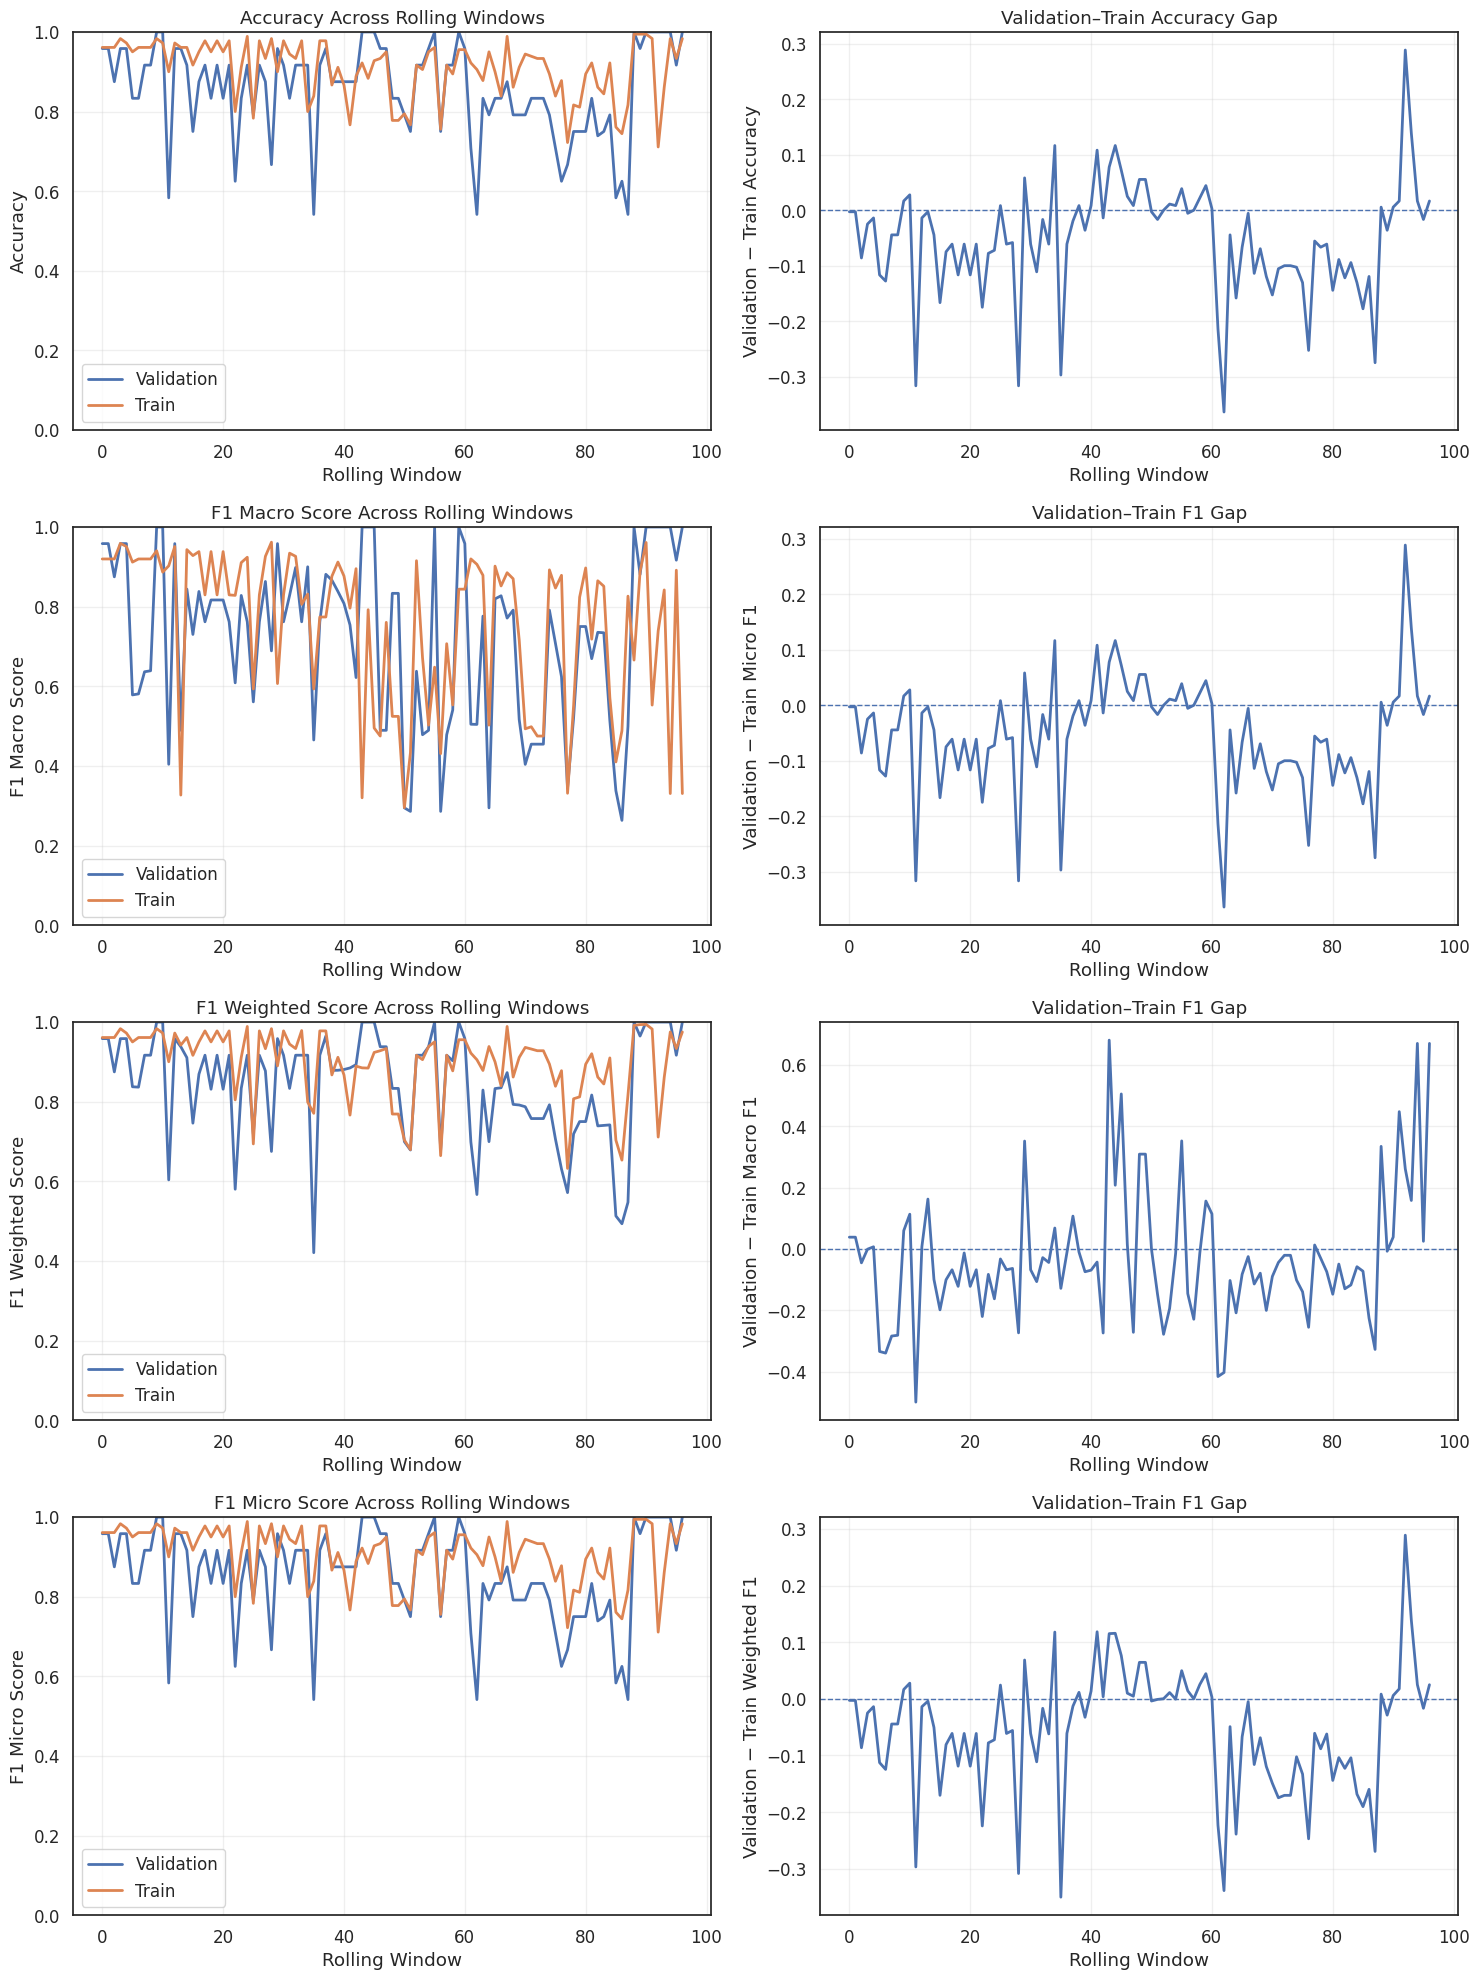


VARIABLES CONNECTED TO NEXT-MONTH OIL REGIME


,variable,count,percentage
0,cl_f,92,94.85
3,PCindustrial_2,3,3.09
2,PCMarket_2,2,2.06
1,PCindustrial_1,2,2.06
4,PCMarket_1,1,1.03
5,world_inv,1,1.03
6,PCDeveloping_1,1,1.03


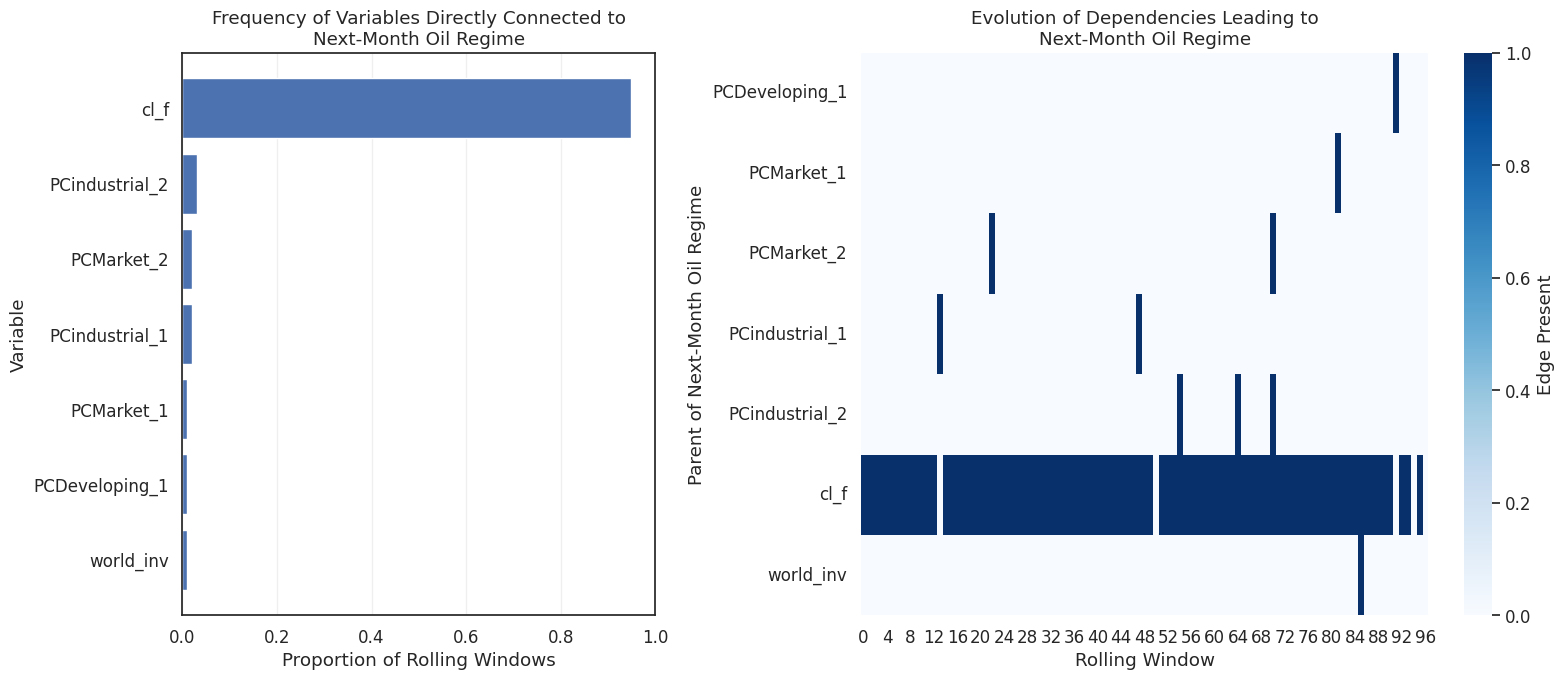

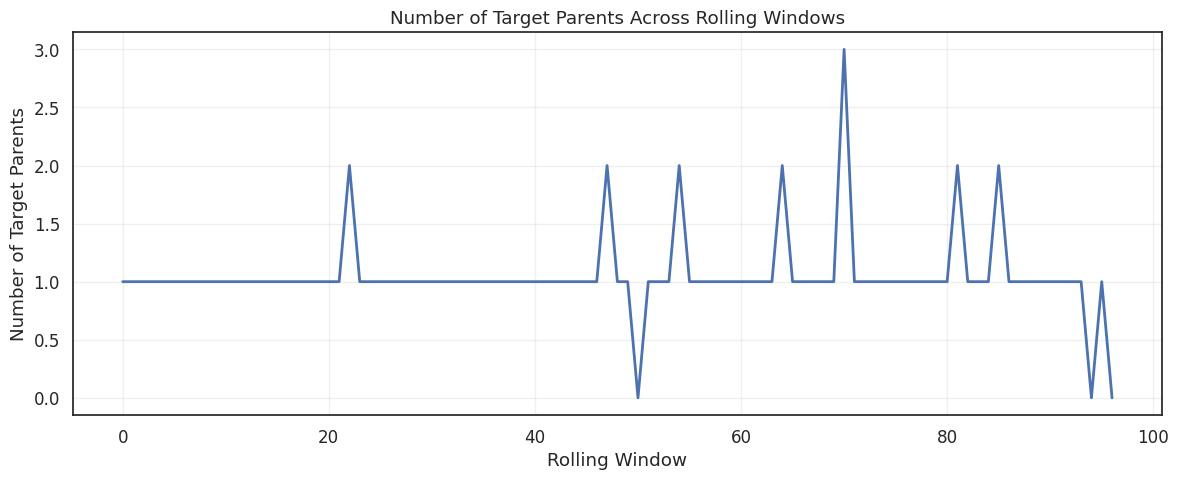

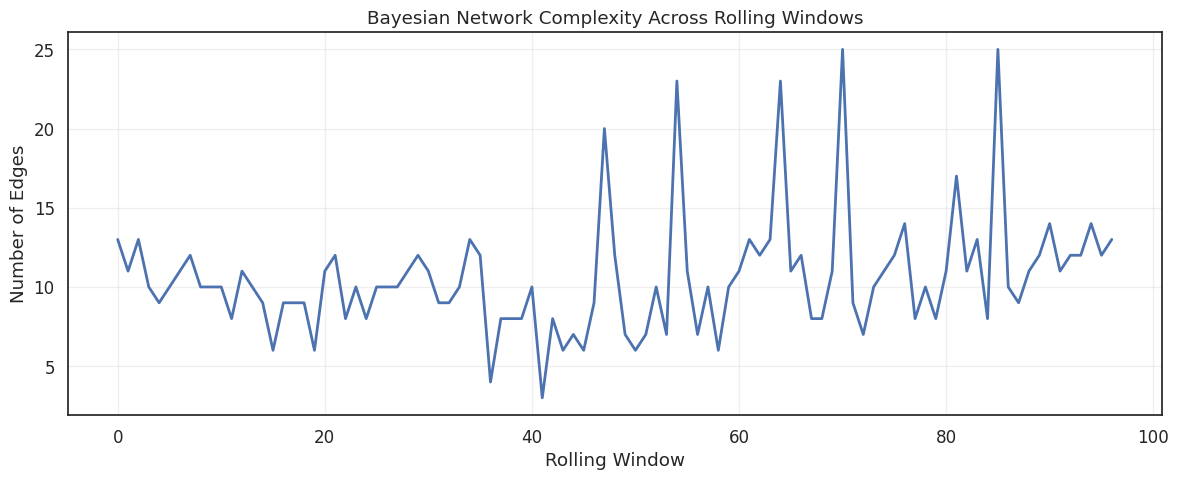


Network complexity:
Mean number of edges: 10.58
Std. deviation:       3.76
Minimum:               3
Maximum:               25


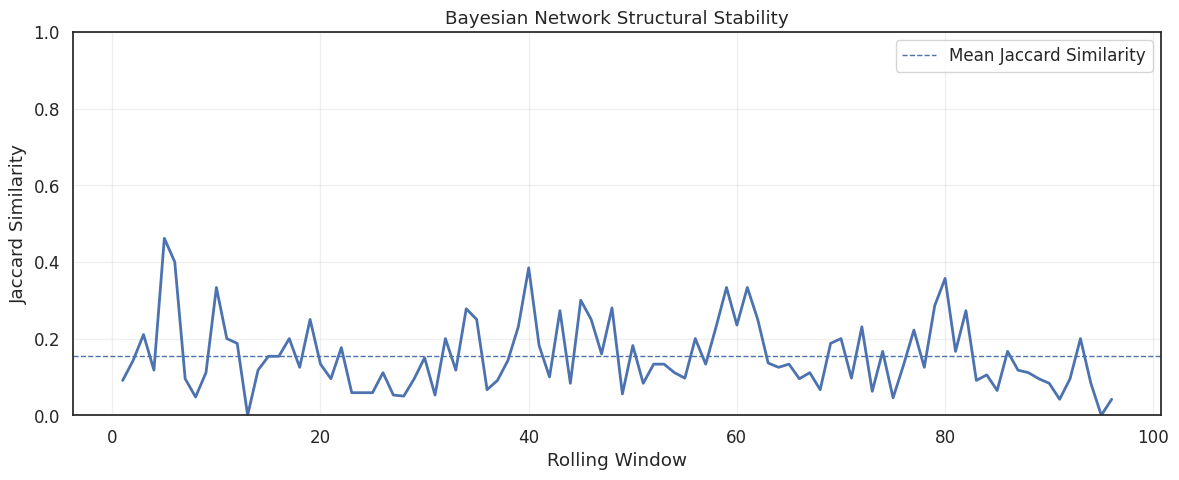


Mean structural similarity: 0.155

MODEL SELECTION FREQUENCY


,Number of Windows,Percentage
HC_BIC,86,88.66
HC_BDeu,6,6.19
PC,5,5.15


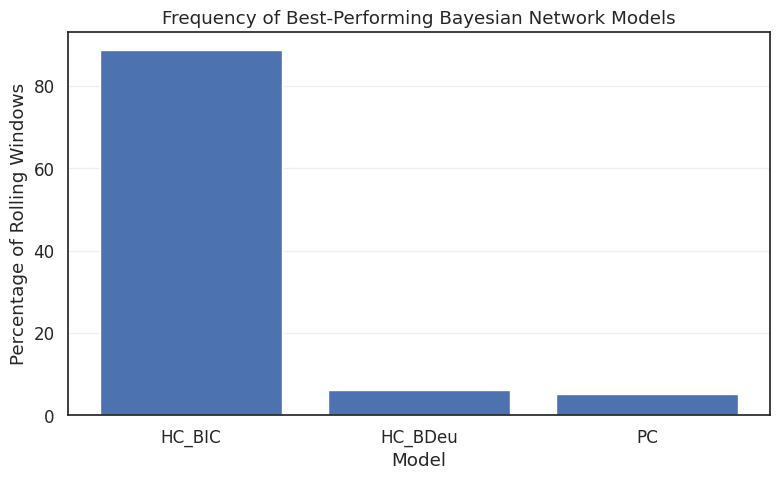


ROLLING WINDOW 0
Best model: HC_BIC
Number of edges: 13

Edges:
  world_inv → Temp_mean_anom
  geo_risk → Temp_mean_anom
  geo_risk → world_inv
  geo_risk → PCDeveloping_2
  cl_f → target
  cl_f → PCindustrial_1
  PCindustrial_1 → geo_risk
  PCindustrial_1 → PCMarket_2
  supply → PCindustrial_2
  supply → demand
  supply → cl_f
  supply → geo_risk
  PCindustrial_2 → PCindustrial_1


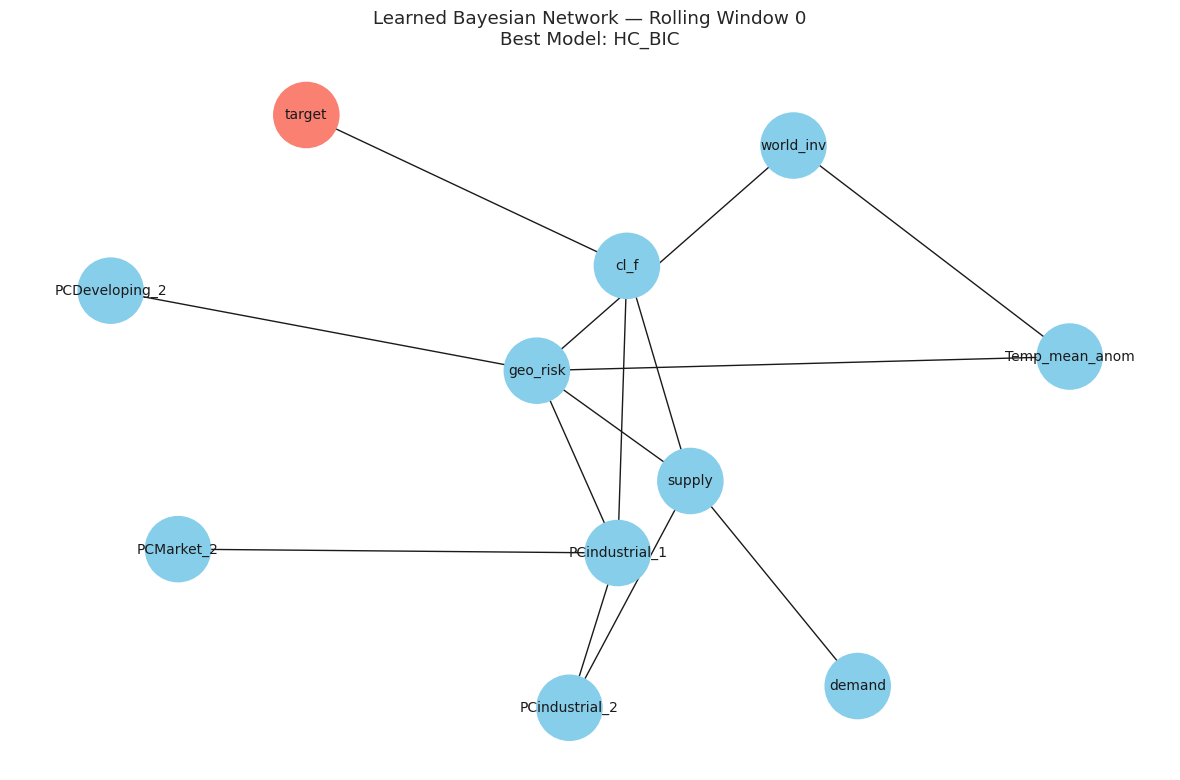

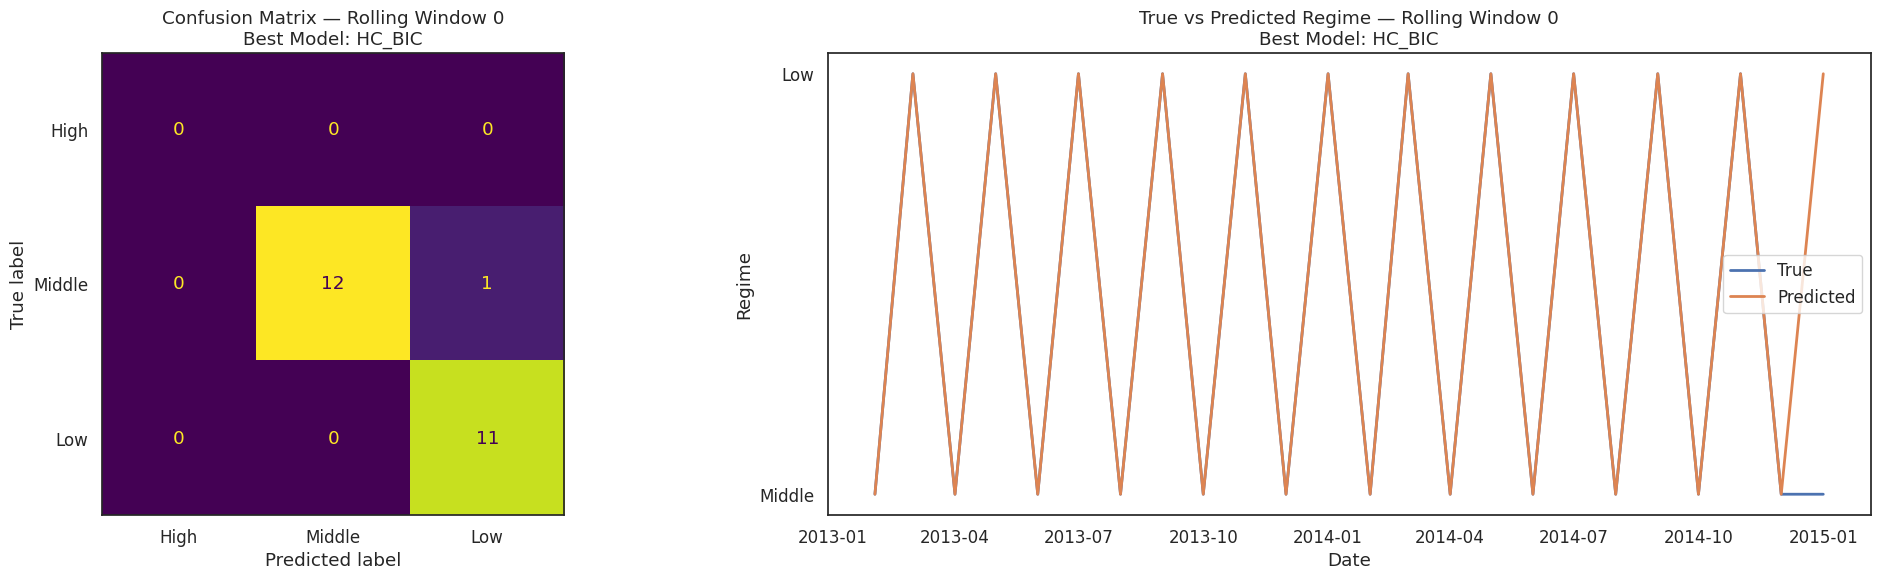


ROLLING WINDOW 20
Best model: HC_BIC
Number of edges: 11

Edges:
  world_inv → demand
  demand → geo_risk
  geo_risk → cl_f
  geo_risk → Temp_mean_anom
  cl_f → target
  cl_f → PCMarket_2
  cl_f → PCindustrial_2
  cl_f → PCindustrial_1
  PCMarket_2 → PCMarket_1
  PCindustrial_2 → PCMarket_1
  PCindustrial_2 → Temp_mean_anom


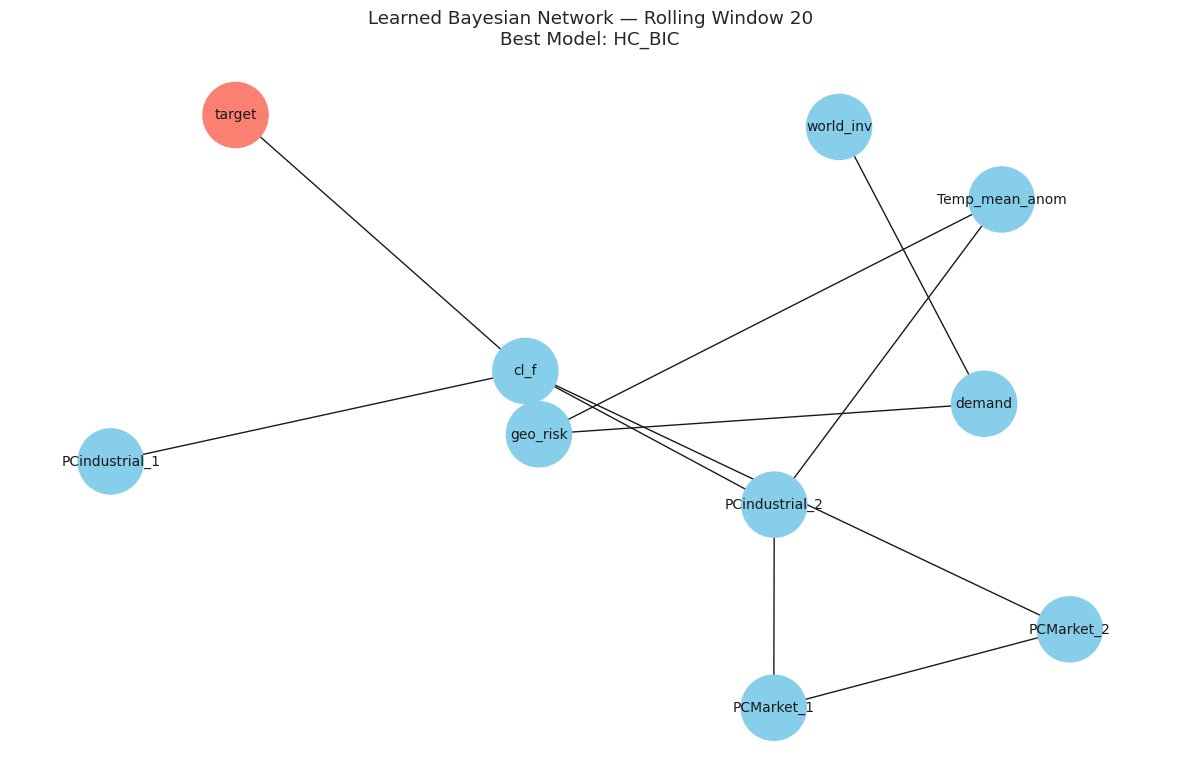

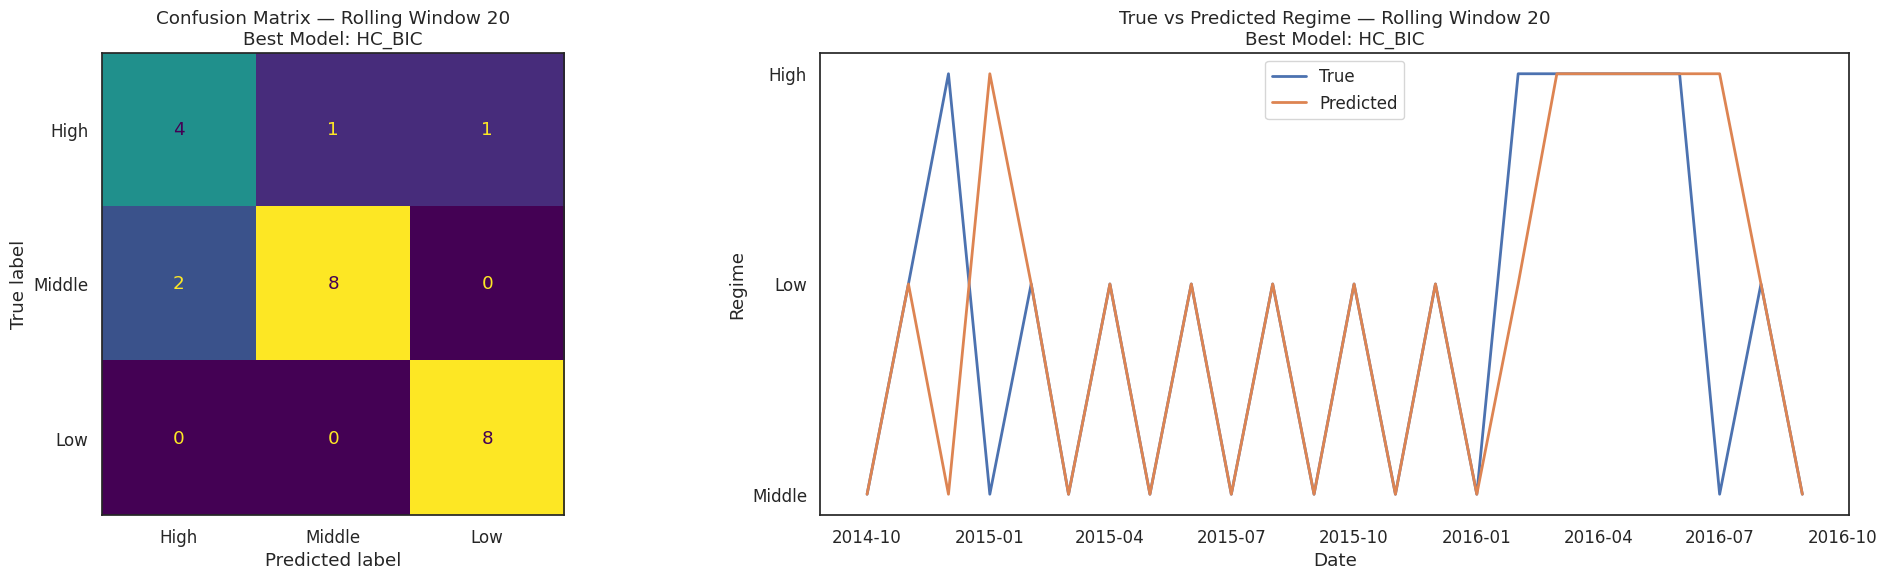


ROLLING WINDOW 40
Best model: HC_BIC
Number of edges: 10

Edges:
  geo_risk → supply
  supply → PCindustrial_2
  cl_f → target
  cl_f → Temp_mean_anom
  PCindustrial_2 → cl_f
  demand → world_inv
  PCindustrial_1 → demand
  PCindustrial_1 → PCMarket_1
  PCindustrial_1 → PCindustrial_2
  PCMarket_1 → cl_f


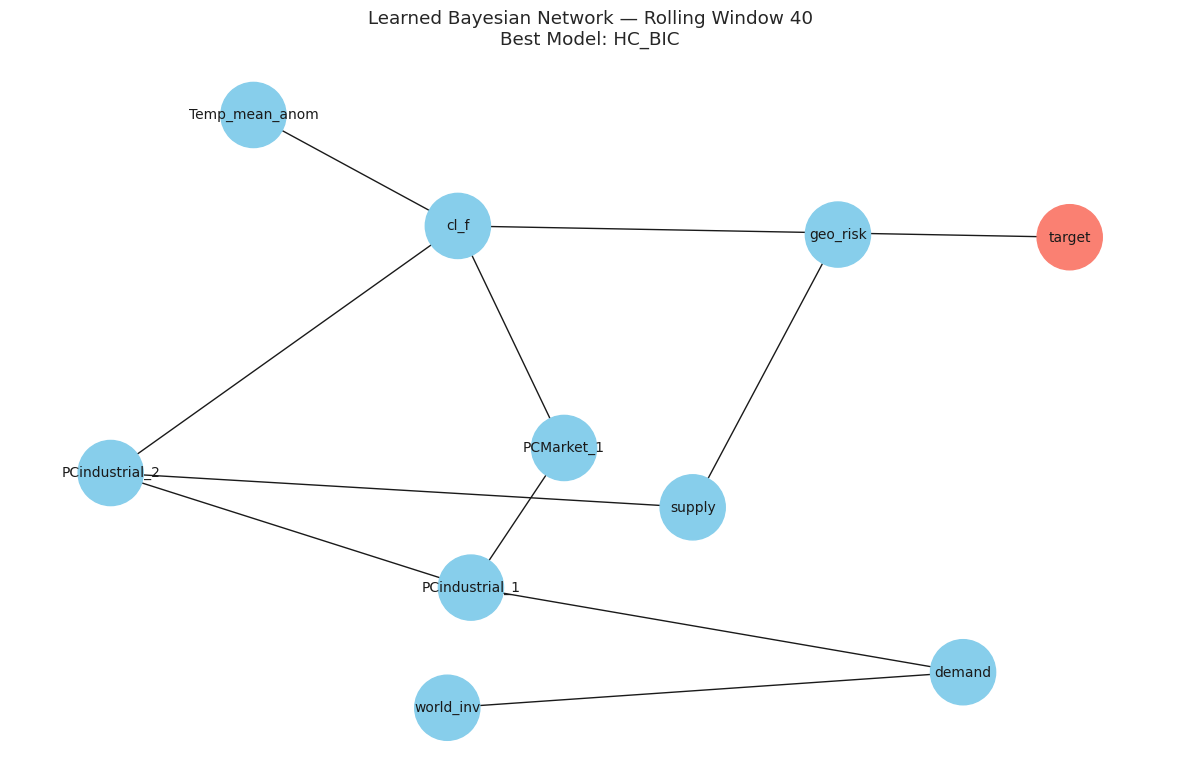

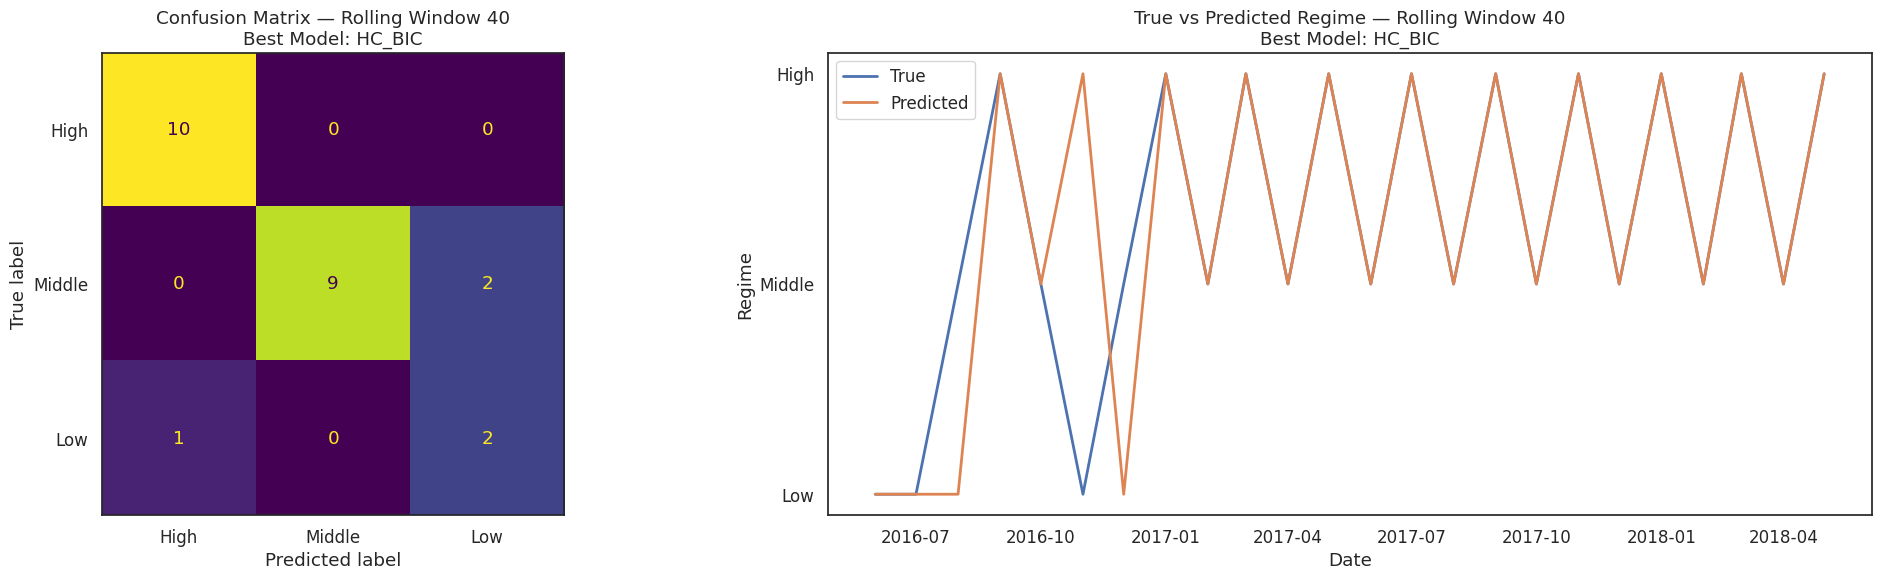


ROLLING WINDOW 60
Best model: HC_BIC
Number of edges: 11

Edges:
  Temp_mean_anom → geo_risk
  cl_f → target
  cl_f → geo_risk
  supply → cl_f
  demand → Temp_mean_anom
  demand → world_inv
  PCindustrial_2 → supply
  PCindustrial_2 → PCMarket_2
  PCDeveloping_1 → demand
  PCDeveloping_1 → PCindustrial_2
  PCDeveloping_1 → Temp_mean_anom


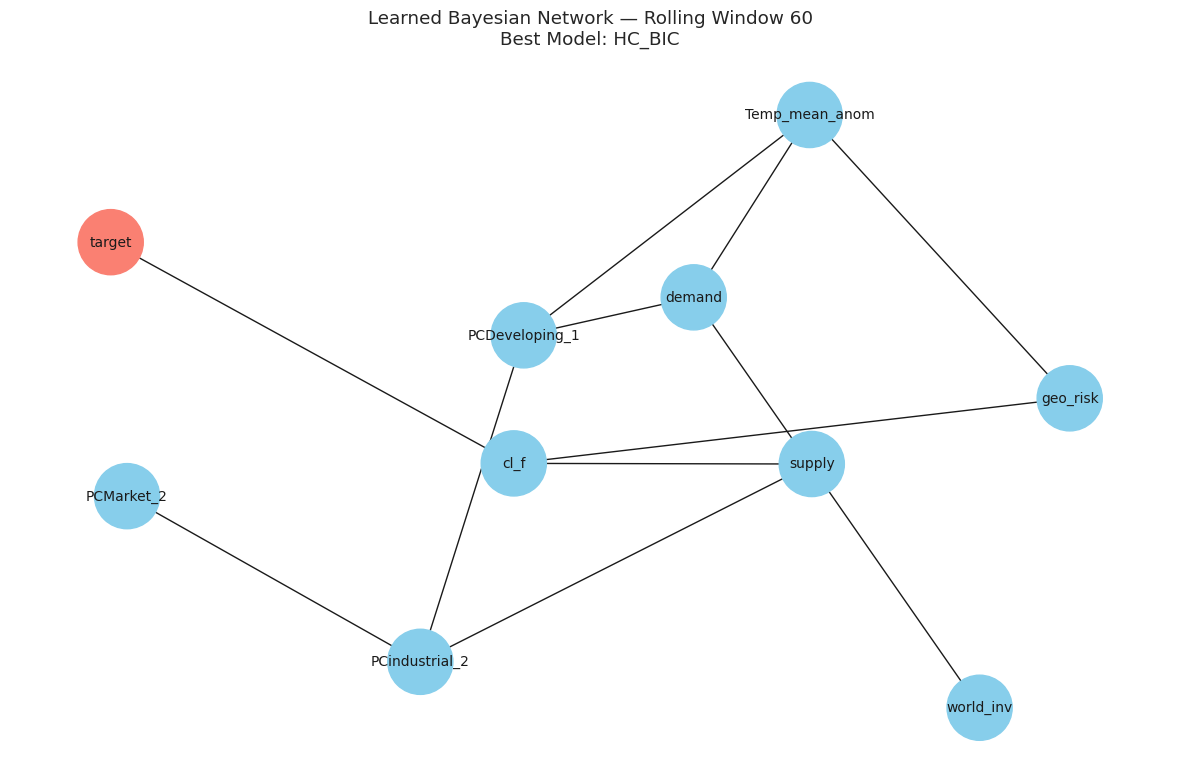

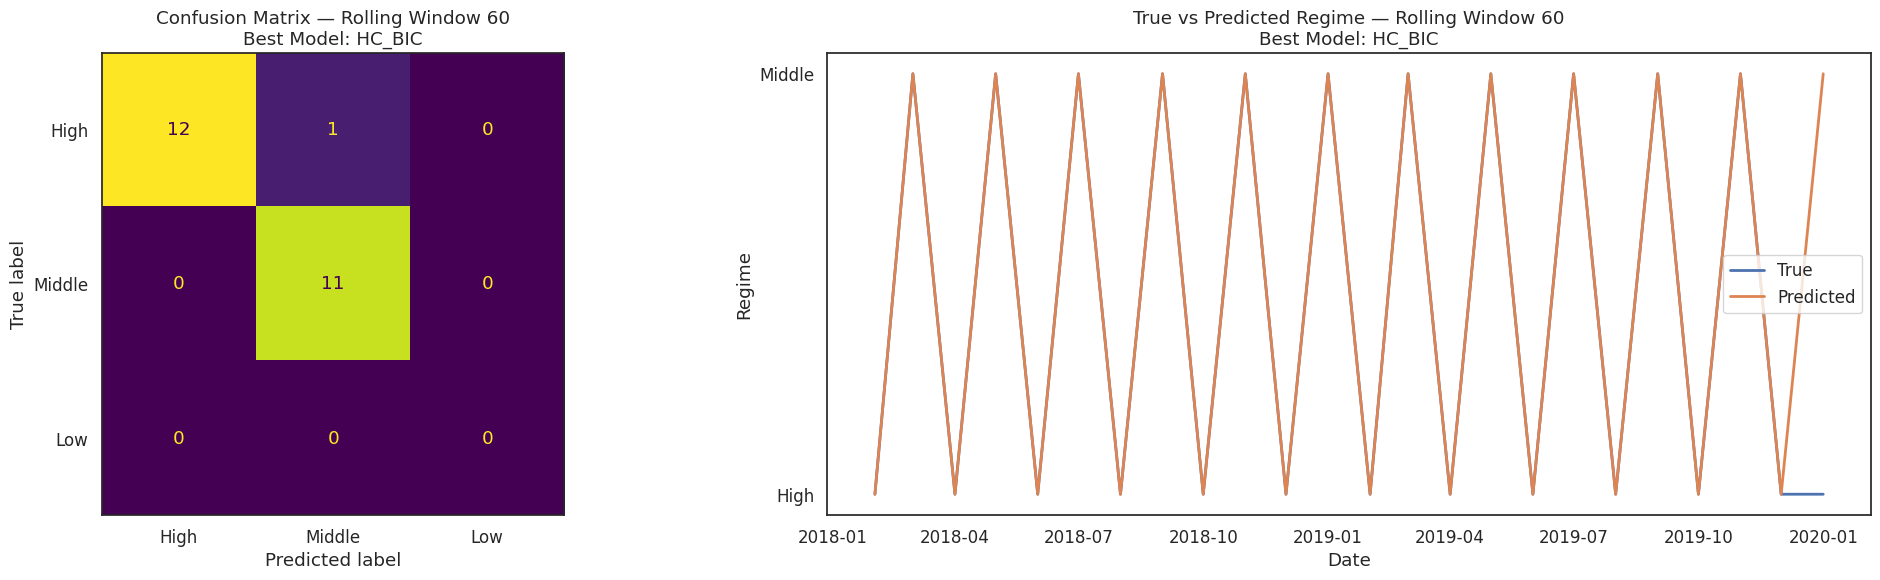


ROLLING WINDOW 80
Best model: HC_BIC
Number of edges: 11

Edges:
  world_inv → PCindustrial_2
  PCindustrial_2 → supply
  PCindustrial_2 → cl_f
  geo_risk → Temp_mean_anom
  cl_f → target
  demand → world_inv
  demand → PCDeveloping_1
  demand → PCMarket_1
  PCMarket_1 → cl_f
  PCMarket_1 → PCindustrial_1
  PCMarket_1 → geo_risk


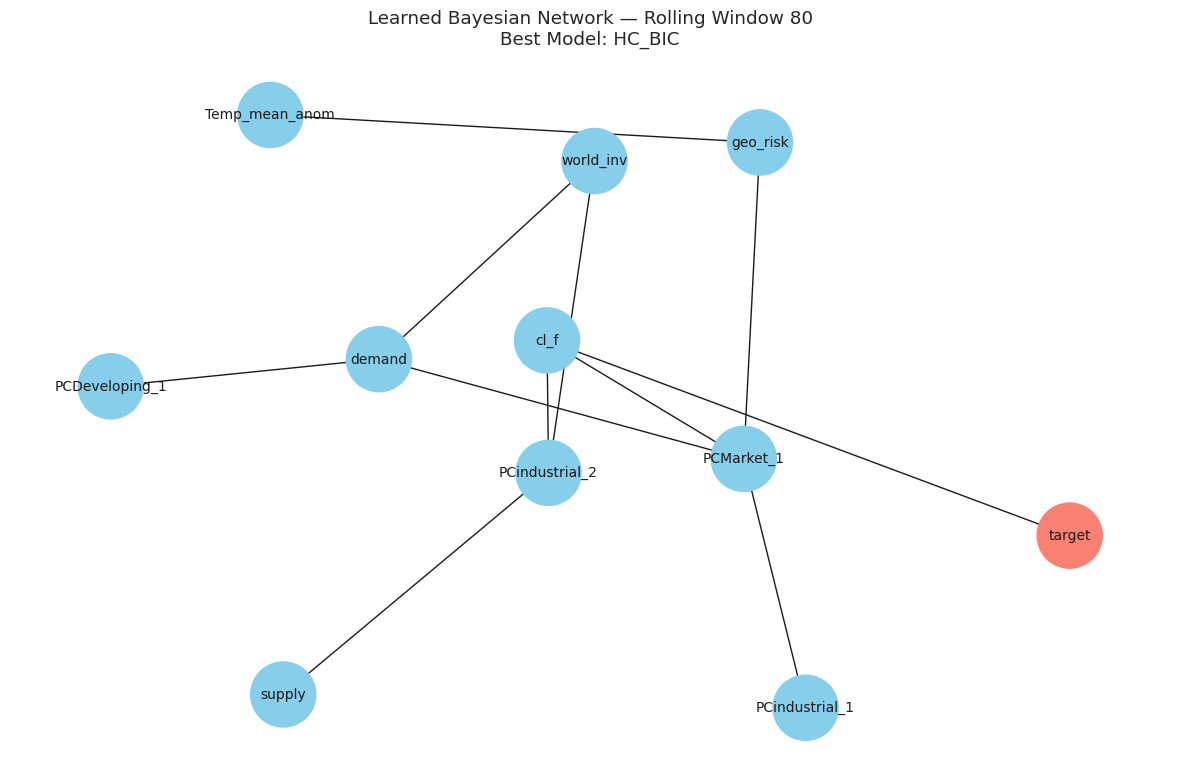

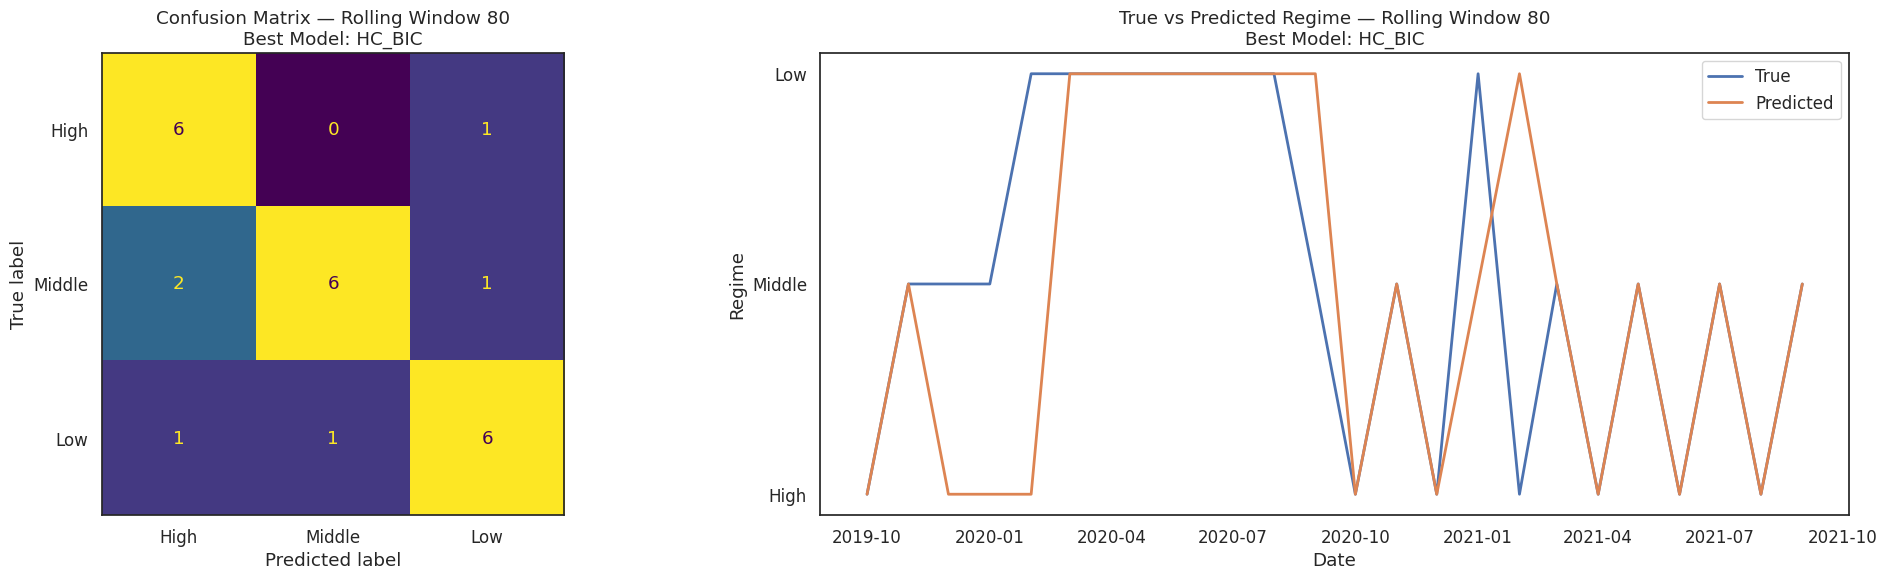

In [ ]:
import networkx as nx
from collections import Counter
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)

# 1. RESULTS DATAFRAME
results_df = pd.DataFrame(results).set_index("window")
print("=" * 80)
print("BASELINE MODEL — ROLLING-WINDOW RESULTS")
print("=" * 80)
display(results_df[["train_accuracy","validation_accuracy",
                    "train_f1_macro","train_f1_weighted", "train_f1_micro",
                    "val_f1_macro","val_f1_weighted","val_f1_micro",]].round(3).head())

# 2. SUMMARY STATISTICS
metric_cols = ["train_accuracy","validation_accuracy",
                    "train_f1_macro","train_f1_weighted", "train_f1_micro",
                    "val_f1_macro","val_f1_weighted","val_f1_micro",]


summary = pd.DataFrame({"Mean": results_df[metric_cols].mean(),"Std. Dev.": results_df[metric_cols].std(),
                        "Minimum": results_df[metric_cols].min(),"Maximum": results_df[metric_cols].max()})
print("\n" + "=" * 80)
print("BASELINE MODEL — PERFORMANCE SUMMARY")
print("=" * 80)
display(summary.round(3))

# VALIDATION-TEST PERFORMANCE GAP
results_df["accuracy_gap"] = (results_df["validation_accuracy"]- results_df["train_accuracy"])
results_df["f1_micro_gap"] = (results_df["val_f1_micro"]- results_df["train_f1_micro"])
results_df["f1_macro_gap"] = (results_df["val_f1_macro"]- results_df["train_f1_macro"])
results_df["f1_weighted_gap"] = (results_df["val_f1_weighted"]- results_df["train_f1_weighted"])

#  VALIDATION VS TEST PERFORMANCE OVER TIME
fig, ax = plt.subplots(4, 2, figsize=(15, 20))

# Accuracy
ax[0,0].plot(results_df.index,results_df["validation_accuracy"],label="Validation",linewidth=2)
ax[0,0].plot(results_df.index,results_df["train_accuracy"],label="Train",linewidth=2)
ax[0,0].set_xlabel("Rolling Window")
ax[0,0].set_ylabel("Accuracy")
ax[0,0].set_title("Accuracy Across Rolling Windows")
ax[0,0].set_ylim(0, 1)
ax[0,0].legend()
ax[0,0].grid(alpha=0.3)

ax[0,1].plot(results_df.index,results_df["accuracy_gap"],linewidth=2)
ax[0,1].axhline(0, linestyle="--", linewidth=1)
ax[0,1].set_xlabel("Rolling Window")
ax[0,1].set_ylabel("Validation − Train Accuracy")
ax[0,1].set_title("Validation–Train Accuracy Gap")
ax[0,1].grid(alpha=0.3)

# F1_macro
ax[1,0].plot(results_df.index,results_df["val_f1_macro"],label="Validation",linewidth=2)
ax[1,0].plot(results_df.index,results_df["train_f1_macro"],label="Train",linewidth=2)
ax[1,0].set_xlabel("Rolling Window")
ax[1,0].set_ylabel("F1 Macro Score")
ax[1,0].set_title("F1 Macro Score Across Rolling Windows")
ax[1,0].set_ylim(0, 1)
ax[1,0].legend()
ax[1,0].grid(alpha=0.3)

ax[1,1].plot(results_df.index,results_df["f1_micro_gap"],linewidth=2)
ax[1,1].axhline(0, linestyle="--", linewidth=1)
ax[1,1].set_xlabel("Rolling Window")
ax[1,1].set_ylabel("Validation − Train Micro F1")
ax[1,1].set_title("Validation–Train F1 Gap")
ax[1,1].grid(alpha=0.3)

# F1_weighted
ax[2,0].plot(results_df.index,results_df["val_f1_weighted"],label="Validation",linewidth=2)
ax[2,0].plot(results_df.index,results_df["train_f1_weighted"],label="Train",linewidth=2)
ax[2,0].set_xlabel("Rolling Window")
ax[2,0].set_ylabel("F1 Weighted Score")
ax[2,0].set_title("F1 Weighted Score Across Rolling Windows")
ax[2,0].set_ylim(0, 1)
ax[2,0].legend()
ax[2,0].grid(alpha=0.3)

ax[2,1].plot(results_df.index,results_df["f1_macro_gap"],linewidth=2)
ax[2,1].axhline(0, linestyle="--", linewidth=1)
ax[2,1].set_xlabel("Rolling Window")
ax[2,1].set_ylabel("Validation − Train Macro F1")
ax[2,1].set_title("Validation–Train F1 Gap")
ax[2,1].grid(alpha=0.3)

# F1_micror
ax[3,0].plot(results_df.index,results_df["val_f1_micro"],label="Validation",linewidth=2)
ax[3,0].plot(results_df.index,results_df["train_f1_micro"],label="Train",linewidth=2)
ax[3,0].set_xlabel("Rolling Window")
ax[3,0].set_ylabel("F1 Micro Score")
ax[3,0].set_title("F1 Micro Score Across Rolling Windows")
ax[3,0].set_ylim(0, 1)
ax[3,0].legend()
ax[3,0].grid(alpha=0.3)

ax[3,1].plot(results_df.index,results_df["f1_weighted_gap"],linewidth=2)
ax[3,1].axhline(0, linestyle="--", linewidth=1)
ax[3,1].set_xlabel("Rolling Window")
ax[3,1].set_ylabel("Validation − Train Weighted F1")
ax[3,1].set_title("Validation–Train F1 Gap")
ax[3,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# 5. FREQUENCY OF VARIABLES CONNECTED TO THE TARGET
target_parent_counts = Counter()
for r in results:
    for parent in r["target_parents"]:
        target_parent_counts[parent] += 1
target_parent_frequency = pd.DataFrame(target_parent_counts.items(),columns=["variable", "count"])
target_parent_frequency["frequency"] = (target_parent_frequency["count"] / len(results))
target_parent_frequency["percentage"] = (target_parent_frequency["frequency"] * 100)
freq = target_parent_frequency.sort_values("frequency",ascending=True)

print("\n" + "=" * 80)
print("VARIABLES CONNECTED TO NEXT-MONTH OIL REGIME")
print("=" * 80)

display(freq[["variable", "count", "percentage"]].sort_values("percentage",ascending=False).round(2))


# 6. VARIABLE FREQUENCY + EVOLUTION HEATMAP
fig, ax = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1, 1.5]})

# ---- Left: Frequency ----
ax[0].barh(freq["variable"],freq["frequency"])
ax[0].set_xlabel("Proportion of Rolling Windows")
ax[0].set_ylabel("Variable")
ax[0].set_title("Frequency of Variables Directly Connected to\n"
    "Next-Month Oil Regime")
ax[0].set_xlim(0, 1)
ax[0].grid(axis="x", alpha=0.3)

# ---- Right: Evolution ----
all_target_parents = sorted(set(parent for r in results for parent in r["target_parents"]))
target_edge_matrix = pd.DataFrame(0,index=range(len(results)),columns=all_target_parents)
for r in results:
    w = r["window"]
    for parent in r["target_parents"]:
        target_edge_matrix.loc[w, parent] = 1
sns.heatmap(target_edge_matrix.T,cmap="Blues",cbar_kws={"label": "Edge Present"},ax=ax[1])
ax[1].set_xlabel("Rolling Window")
ax[1].set_ylabel("Parent of Next-Month Oil Regime")
ax[1].set_title("Evolution of Dependencies Leading to\n"
    "Next-Month Oil Regime")

plt.tight_layout()
plt.show()


# 7. NUMBER OF EDGES — NETWORK COMPLEXITY
edge_counts = [len(r["target_parents"]) for r in results]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(edge_counts)),edge_counts,linewidth=2)
ax.set_xlabel("Rolling Window")
ax.set_ylabel("Number of Target Parents")
ax.set_title("Number of Target Parents Across Rolling Windows")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 7. NUMBER OF target parents
edge_counts = [len(r["edges"]) for r in results]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(edge_counts)),edge_counts,linewidth=2)
ax.set_xlabel("Rolling Window")
ax.set_ylabel("Number of Edges")
ax.set_title("Bayesian Network Complexity Across Rolling Windows")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNetwork complexity:")
print(f"Mean number of edges: {np.mean(edge_counts):.2f}")
print(f"Std. deviation:       {np.std(edge_counts):.2f}")
print(f"Minimum:               {np.min(edge_counts)}")
print(f"Maximum:               {np.max(edge_counts)}")


# 8. GRAPH STRUCTURAL STABILITY
def edge_jaccard(edges1, edges2):
    e1 = set(edges1)
    e2 = set(edges2)
    if len(e1) == 0 and len(e2) == 0:
        return 1.0
    union = e1 | e2
    if len(union) == 0:
        return 1.0
    return len(e1 & e2) / len(union)

graph_stability = []
for i in range(1, len(results)):
    similarity = edge_jaccard(results[i - 1]["edges"],results[i]["edges"])
    graph_stability.append({"window": i,"jaccard_similarity": similarity})
graph_stability_df = pd.DataFrame(graph_stability)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(graph_stability_df["window"],graph_stability_df["jaccard_similarity"],linewidth=2)
ax.axhline(graph_stability_df["jaccard_similarity"].mean(),linestyle="--", linewidth=1,label="Mean Jaccard Similarity")
ax.set_xlabel("Rolling Window")
ax.set_ylabel("Jaccard Similarity")
ax.set_title("Bayesian Network Structural Stability")

ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMean structural similarity: "
    f"{graph_stability_df['jaccard_similarity'].mean():.3f}")


# 9. HOW OFTEN DOES EACH METHOD WIN?
model_frequency = (pd.Series([r["best_model"] for r in results]).value_counts())
model_frequency_pct = (model_frequency / len(results) * 100)
model_summary = pd.DataFrame({"Number of Windows": model_frequency,"Percentage": model_frequency_pct})
print("\n" + "=" * 80)
print("MODEL SELECTION FREQUENCY")
print("=" * 80)

display(model_summary.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(model_summary.index,model_summary["Percentage"])
ax.set_ylabel("Percentage of Rolling Windows")
ax.set_xlabel("Model")
ax.set_title("Frequency of Best-Performing Bayesian Network Models")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# 10. SELECTED NETWORK STRUCTURES

selected_windows = [w for w in [0, 20, 40, 60, 80, 99] if w < len(results)]

labels = ["High", "Middle", "Low"]

for w in selected_windows:

    r = results[w]

    print("\n" + "=" * 80)
    print(f"ROLLING WINDOW {w}")
    print("=" * 80)

    print(f"Best model: {r['best_model']}")
    print(f"Number of edges: {len(r['edges'])}")

    print("\nEdges:")
    for edge in r["edges"]:
        print(f"  {edge[0]} → {edge[1]}")

    # 1. BAYESIAN NETWORK STRUCTURE
    G = nx.DiGraph()
    G.add_edges_from(r["edges"])

    # Make sure target is shown
    if "target" not in G:
        G.add_node("target")

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G,seed=42,k=1.2)

    node_colors = ["salmon" if node == "target" else "skyblue" for node in G.nodes()]
    nx.draw_networkx_nodes(G,pos,node_size=2200,node_color=node_colors)
    nx.draw_networkx_edges(G,pos,arrows=True,arrowsize=25, arrowstyle="-|>")
    nx.draw_networkx_labels(G,pos,font_size=10)
    plt.title(f"Learned Bayesian Network — Rolling Window {w}\n"
        f"Best Model: {r['best_model']}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    # 2. CONFUSION MATRIX
    cm = confusion_matrix(all_y_true[w],all_y_pred[w],labels=labels)
    fig, ax = plt.subplots(1,2,figsize=(21, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labels)
    disp.plot(ax=ax[0],values_format="d",colorbar=False)
    ax[0].set_title(f"Confusion Matrix — Rolling Window {w}\n"
        f"Best Model: {r['best_model']}")

    # 3. TRUE VS PREDICTED REGIME
    # Use the actual dates corresponding to the predictions.
    test_dates = valid_data_cat[w].index[:len(all_y_true[w])]
    ax[1].plot(test_dates,all_y_true[w],label="True",linewidth=2)
    ax[1].plot(test_dates,all_y_pred[w],label="Predicted",linewidth=2)
    ax[1].set_title(f"True vs Predicted Regime — Rolling Window {w}\n"
        f"Best Model: {r['best_model']}")
    plt.xlabel("Date")
    plt.ylabel("Regime")
    plt.legend()
    plt.tight_layout()
    plt.show()

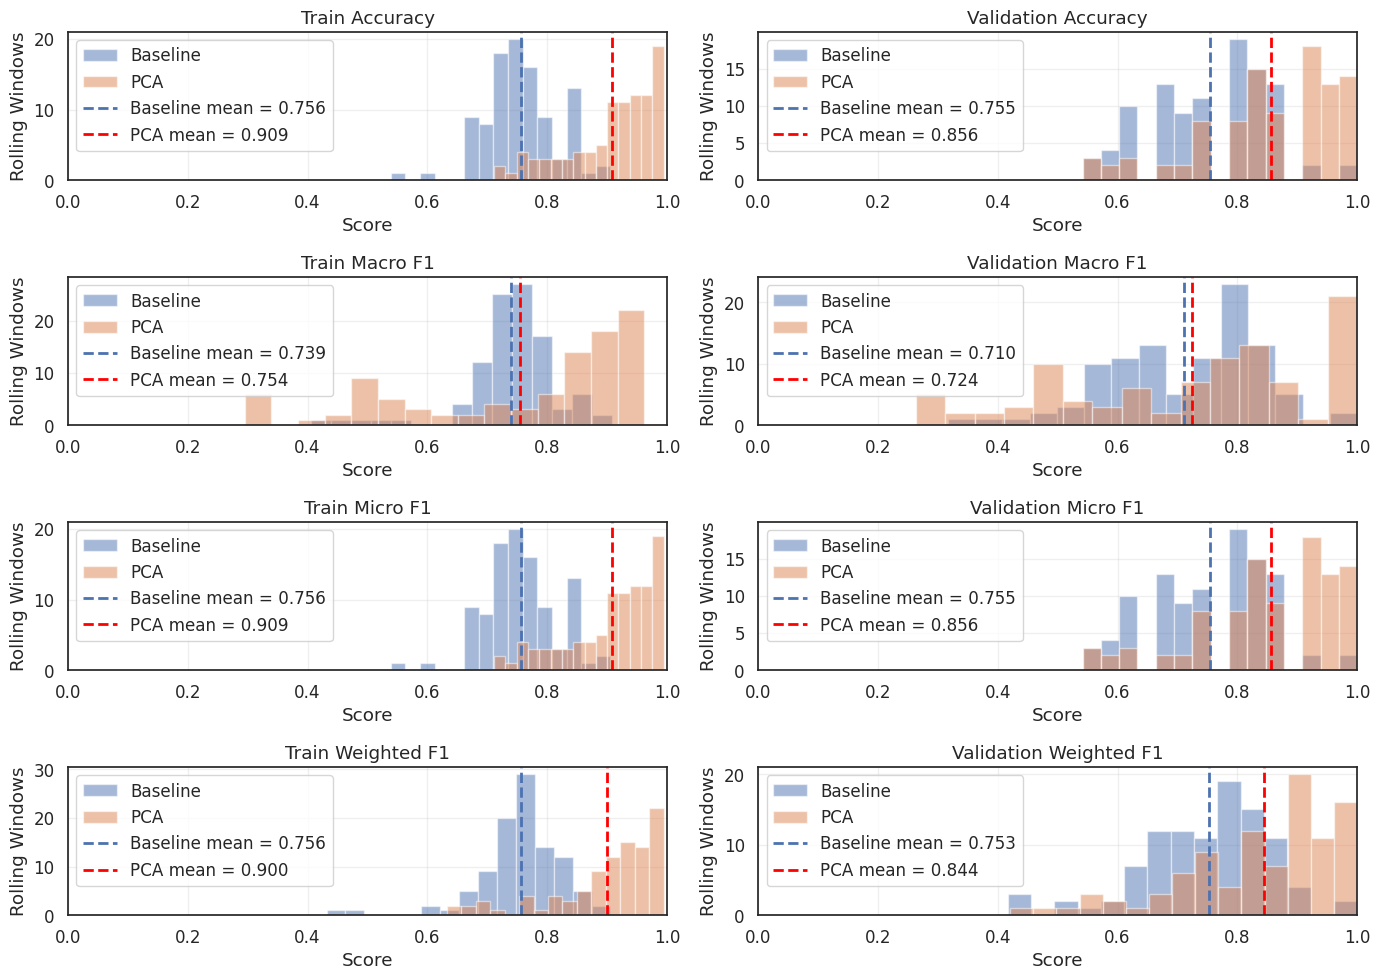

In [ ]:
import matplotlib.pyplot as plt

metrics = ["train_accuracy", "validation_accuracy","train_f1_macro","val_f1_macro",
    "train_f1_micro","val_f1_micro","train_f1_weighted","val_f1_weighted"]
titles = ["Train Accuracy","Validation Accuracy","Train Macro F1", "Validation Macro F1",
    "Train Micro F1","Validation Micro F1","Train Weighted F1","Validation Weighted F1"]

fig, axes = plt.subplots(4, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, metric, title in zip(axes, metrics, titles):
    ax.hist(results_base_df[metric].dropna(),bins=15,alpha=0.5,label="Baseline")
    ax.hist(results_df[metric].dropna(),bins=15,alpha=0.5,label="PCA")
    # Mean lines
    ax.axvline(results_base_df[metric].mean(),linestyle="--",linewidth=2,
        label=f"Baseline mean = {results_base_df[metric].mean():.3f}")
    ax.axvline(results_df[metric].mean(),linestyle="--",linewidth=2,
        label=f"PCA mean = {results_df[metric].mean():.3f}", color = 'red')
    ax.set_title(title)
    ax.set_xlabel("Score")
    ax.set_ylabel("Rolling Windows")
    ax.set_xlim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### **Crude Oil Prediction**

  0%|          | 0/1000000 [00:00<?, ?it/s]

Final BN edges:
[('world_inv', 'PCindustrial_2'), ('cl_f', 'target'), ('supply', 'PCindustrial_1'), ('supply', 'PCDeveloping_2'), ('supply', 'geo_risk'), ('supply', 'Temp_mean_anom'), ('supply', 'world_inv'), ('PCindustrial_1', 'cl_f'), ('PCDeveloping_1', 'demand'), ('PCDeveloping_1', 'supply'), ('PCDeveloping_1', 'PCMarket_2')]

Target parents:
['cl_f']


,prediction_month,predicted_regime,actual_regime
signal_date,,,
2023-03-01,2023-04-01,Middle,Middle
2023-04-01,2023-05-01,Middle,Middle
2023-05-01,2023-06-01,Middle,Middle
2023-06-01,2023-07-01,Middle,Middle
2023-07-01,2023-08-01,Middle,Middle
2023-08-01,2023-09-01,Middle,Middle
2023-09-01,2023-10-01,Middle,Middle
2023-10-01,2023-11-01,Middle,Middle
2023-11-01,2023-12-01,Middle,Middle


Accuracy: 1.0
Macro F1: 1.0
Weighted F1: 1.0
Micro F1: 1.0


,prediction_month,predicted_regime,actual_regime,position,oil_return_next_month,strategy_return
signal_date,,,,,,
2023-03-01,2023-04-01,Middle,Middle,0,0.080823,0.0
2023-04-01,2023-05-01,Middle,Middle,0,-0.104291,-0.0
2023-05-01,2023-06-01,Middle,Middle,0,-0.018757,-0.0
2023-06-01,2023-07-01,Middle,Middle,0,0.079614,0.0
2023-07-01,2023-08-01,Middle,Middle,0,0.067557,0.0
2023-08-01,2023-09-01,Middle,Middle,0,0.094196,0.0
2023-09-01,2023-10-01,Middle,Middle,0,-0.043253,-0.0
2023-10-01,2023-11-01,Middle,Middle,0,-0.097485,-0.0
2023-11-01,2023-12-01,Middle,Middle,0,-0.077386,-0.0


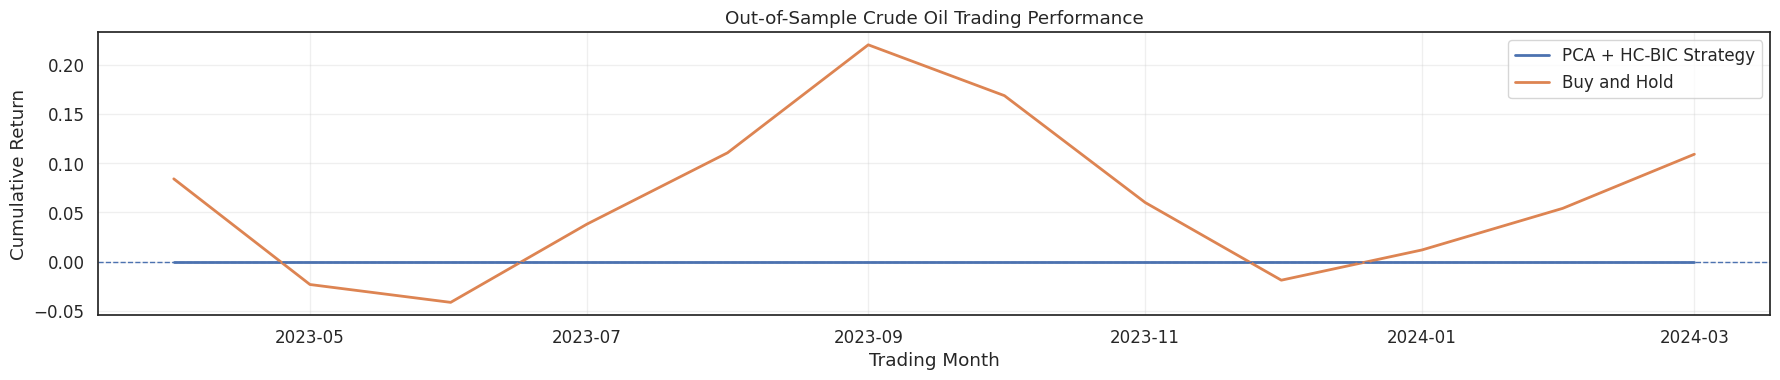

In [ ]:
# FINAL UNSEEN PERIOD
# Model already selected: PCA + HC-BIC

# Exact 15-year history before March 2023
train_raw = df.loc["2008-03-01":"2023-02-01", :].copy()
# 13 observations: # Mar-2023 ... Mar-2024
test_raw = df.loc["2023-03-01":"2024-03-01", :].copy()

train_processed, test_processed,_,_,_ = pre_processing_pca(train_raw, test_raw)

#HMM REGIME DETECTION
regime_train_int = pd.DataFrame(index=train_processed.index)
regime_test_int = pd.DataFrame(index=test_processed.index)
regime_train_cat = pd.DataFrame(index=train_processed.index)
regime_test_cat = pd.DataFrame(index=test_processed.index)

hmm_models = {}
for col in train_processed.columns:
    X_train = train_processed[[col]].values
    X_test = test_processed[[col]].values

    hmm_model = GaussianHMM(n_components=3,covariance_type="full",n_iter=1000,random_state=42)
    # Fit ONLY on training period
    hmm_model.fit(X_train)
    # Sequential filtering of training observations
    train_states, train_probs, last_alpha = filter_gaussian_hmm(hmm_model,X_train)
    # Continue filtering into unseen test period
    test_states, test_probs, _ = filter_gaussian_hmm(hmm_model,X_test,alpha_prev=last_alpha)
    regime_train_int[col] = train_states
    regime_test_int[col] = test_states

    temp = pd.DataFrame({"value": train_processed[col],"state": train_states})
    state_mean = temp.groupby("state")["value"].mean()

    high_state = state_mean.idxmax()
    low_state = state_mean.idxmin()
    mapping = {}
    for state in state_mean.index:
        if state == high_state:
            mapping[state] = "High"
        elif state == low_state:
            mapping[state] = "Low"
        else:
            mapping[state] = "Middle"
    regime_train_cat[col] = (regime_train_int[col].map(mapping))
    regime_test_cat[col] = (regime_test_int[col].map(mapping))
    hmm_models[col] = hmm_model


#  FINAL BAYESIAN NETWORK # PCA + HC-BIC already selected
bn_train = regime_train_cat.copy()
bn_test = regime_test_cat.copy()
# Remove variables constant in TRAIN
constant_cols = [col for col in bn_train.columns if bn_train[col].nunique() <= 1]
bn_train = bn_train.drop(columns=constant_cols)
bn_test = bn_test.drop(columns=constant_cols)

bn_train["target"] = bn_train["cl_f"].shift(-1)
bn_train = bn_train.dropna()

final_model = build_bn(bn_train, HillClimbSearch,BIC,max_indegree=4)
print("Final BN edges:")
print(list(final_model.edges()))
print("\nTarget parents:")
print(final_model.get_parents("target"))

# OUT-OF-SAMPLE NEXT-MONTH PREDICTIONS
infer = VariableElimination(final_model)
# Actual future regime.
actual_target = bn_test["cl_f"].shift(-1)
# Last row cannot be evaluated because we don't have next month's regime after March 2024.
test_for_prediction = bn_test.iloc[:-1].copy()
predictors = [col for col in test_for_prediction.columns if col in final_model.nodes() and col != "target"]

predictions = []

for date, row in test_for_prediction.iterrows():
    evidence = row[predictors].to_dict()
    pred = infer.map_query(variables=["target"],evidence=evidence,show_progress=False)
    predictions.append({"signal_date": date, "prediction_month": date + pd.DateOffset(months=1),"predicted_regime":pred["target"],
                        "actual_regime": actual_target.loc[date]})

prediction_df = pd.DataFrame(predictions)
prediction_df = prediction_df.set_index("signal_date")
display(prediction_df)

# OUT-OF-SAMPLE CLASSIFICATION PERFORMANCE
y_true = prediction_df["actual_regime"]
y_pred = prediction_df["predicted_regime"]


print("Accuracy:",accuracy_score(y_true, y_pred))
print("Macro F1:",f1_score(y_true,y_pred,average="macro",zero_division=0))
print("Weighted F1:",f1_score(y_true,y_pred,average="weighted",zero_division=0))
print("Micro F1:",f1_score(y_true, y_pred, average="micro", zero_division=0))

# TRADING SIGNAL
signal_map = {"High": 1,"Middle": 0,"Low": -1}
prediction_df["position"] = (prediction_df["predicted_regime"].map(signal_map))

# NEXT-MONTH OIL RETURN
future_oil_return = test_raw["cl_f"].shift(-1)
prediction_df["oil_return_next_month"] = (future_oil_return.loc[prediction_df.index])

# Strategy return
prediction_df["strategy_return"] = (prediction_df["position"] * prediction_df["oil_return_next_month"])

display(prediction_df[["prediction_month","predicted_regime","actual_regime","position","oil_return_next_month","strategy_return"]])

prediction_df["strategy_cumulative"] = (np.exp(prediction_df["strategy_return"].cumsum()) - 1)
prediction_df["buy_hold_cumulative"] = (np.exp(prediction_df["oil_return_next_month"].cumsum()) - 1)
# PLOT
plt.figure(figsize=(18, 4))
plt.plot(prediction_df["prediction_month"],prediction_df["strategy_cumulative"],label="PCA + HC-BIC Strategy", linewidth=2)
plt.plot(prediction_df["prediction_month"],prediction_df["buy_hold_cumulative"],label="Buy and Hold",linewidth=2)
plt.axhline( 0,linestyle="--",linewidth=1)
plt.xlabel("Trading Month")
plt.ylabel("Cumulative Return")
plt.title("Out-of-Sample Crude Oil Trading Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### **Temporal Evolution of the Bayesian Network Structure.**

Did the Bayesian Network structure change around COVID?


Pre-COVID (2004-2018)


  0%|          | 0/1000000 [00:00<?, ?it/s]

Observations used: 179
Number of edges: 13
Target parents: ['cl_f']
cl_f parents: ['Temp_mean_anom']
cl_f children: ['target', 'PCMarket_1']

Edges:
  Temp_mean_anom -> cl_f
  Temp_mean_anom -> PCMarket_1
  cl_f -> target
  cl_f -> PCMarket_1
  PCMarket_1 -> PCindustrial_2
  PCMarket_1 -> PCDeveloping_2
  geo_risk -> PCMarket_2
  geo_risk -> Temp_mean_anom
  PCMarket_2 -> supply
  supply -> demand
  demand -> Temp_mean_anom
  PCindustrial_2 -> PCDeveloping_1
  PCDeveloping_1 -> PCindustrial_1

Local Independecies given the parent nodes: Pre-COVID (2004-2018)
(PCDeveloping_1 ⟂ PCDeveloping_2, PCMarket_1, PCMarket_2, Temp_mean_anom, cl_f, demand, geo_risk, supply, target, world_inv | PCindustrial_2)
(PCDeveloping_2 ⟂ PCDeveloping_1, PCMarket_2, PCindustrial_1, PCindustrial_2, Temp_mean_anom, cl_f, demand, geo_risk, supply, target, world_inv | PCMarket_1)
(PCMarket_1 ⟂ PCMarket_2, demand, geo_risk, supply, target, world_inv | Temp_mean_anom, cl_f)
(PCMarket_2 ⟂ world_inv | geo_risk)
(PCin

  0%|          | 0/1000000 [00:00<?, ?it/s]

Observations used: 179
Number of edges: 13
Target parents: ['cl_f']
cl_f parents: ['PCDeveloping_2']
cl_f children: ['target', 'Temp_mean_anom', 'PCDeveloping_1']

Edges:
  Temp_mean_anom -> world_inv
  Temp_mean_anom -> geo_risk
  world_inv -> PCindustrial_2
  geo_risk -> PCMarket_1
  cl_f -> target
  cl_f -> Temp_mean_anom
  cl_f -> PCDeveloping_1
  supply -> PCindustrial_1
  PCindustrial_1 -> PCDeveloping_2
  PCindustrial_1 -> geo_risk
  PCindustrial_1 -> PCMarket_2
  PCDeveloping_2 -> cl_f
  PCDeveloping_2 -> demand

Local Independecies given the parent nodes: COVID-inclusive (2006-2020)
(PCDeveloping_1 ⟂ PCDeveloping_2, PCMarket_1, PCMarket_2, PCindustrial_1, PCindustrial_2, Temp_mean_anom, demand, geo_risk, supply, target, world_inv | cl_f)
(PCDeveloping_2 ⟂ PCMarket_2, supply | PCindustrial_1)
(PCMarket_1 ⟂ PCDeveloping_1, PCDeveloping_2, PCMarket_2, PCindustrial_1, PCindustrial_2, Temp_mean_anom, cl_f, demand, supply, target, world_inv | geo_risk)
(PCMarket_2 ⟂ PCDeveloping_1, 

...


Developing-country PCA loadings


,PC1,PC2
china_inds,0.669636,0.101400
russia_inds,-0.614860,-0.479958
india_inds,-0.416575,0.871412



Industrial PCA loadings


,PC1,PC2
oecd_inds,0.549021,-0.022823
us_inds,0.658058,0.039185
IPG21112S,0.376608,0.594316
A24STI,0.298440,-0.341111
CAPUTLG211S,-0.186106,0.726895



NETWORK STRUCTURAL COMPARISON
Pre-COVID (2004-2018) vs COVID-inclusive (2006-2020): Jaccard = 0.040
COVID-inclusive (2006-2020) vs Later period (2010-2024): Jaccard = 0.100
Pre-COVID (2004-2018) vs Later period (2010-2024): Jaccard = 0.048

Pre-COVID (2004-2018)  ->  COVID-inclusive (2006-2020)

Persistent edges:
  cl_f -> target

New edges:
  PCDeveloping_2 -> cl_f
  PCDeveloping_2 -> demand
  PCindustrial_1 -> PCDeveloping_2
  PCindustrial_1 -> PCMarket_2
  PCindustrial_1 -> geo_risk
  Temp_mean_anom -> geo_risk
  Temp_mean_anom -> world_inv
  cl_f -> PCDeveloping_1
  cl_f -> Temp_mean_anom
  geo_risk -> PCMarket_1
  supply -> PCindustrial_1
  world_inv -> PCindustrial_2

Disappeared edges:
  PCDeveloping_1 -> PCindustrial_1
  PCMarket_1 -> PCDeveloping_2
  PCMarket_1 -> PCindustrial_2
  PCMarket_2 -> supply
  PCindustrial_2 -> PCDeveloping_1
  Temp_mean_anom -> PCMarket_1
  Temp_mean_anom -> cl_f
  cl_f -> PCMarket_1
  demand -> Temp_mean_anom
  geo_risk -> PCMarket_2
  geo_risk ->

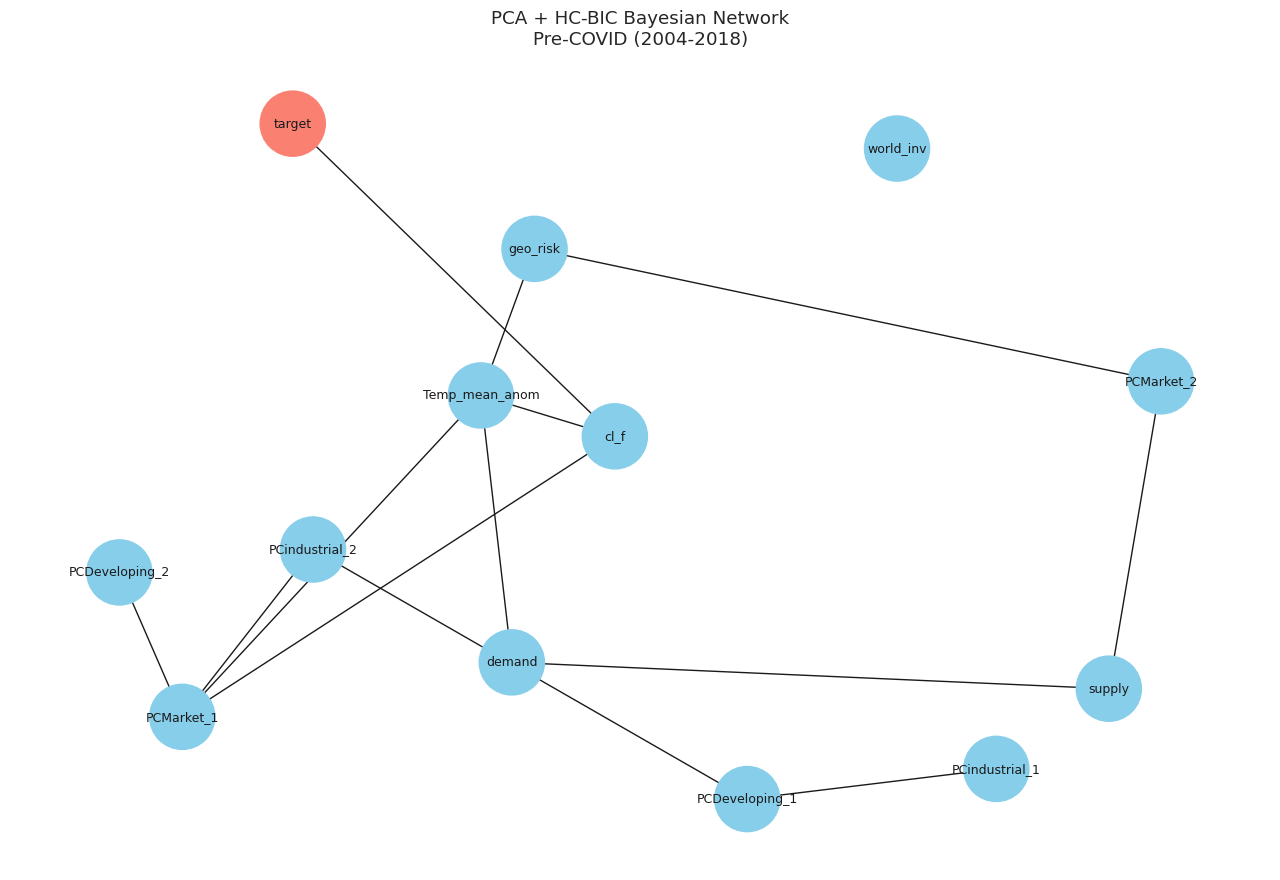

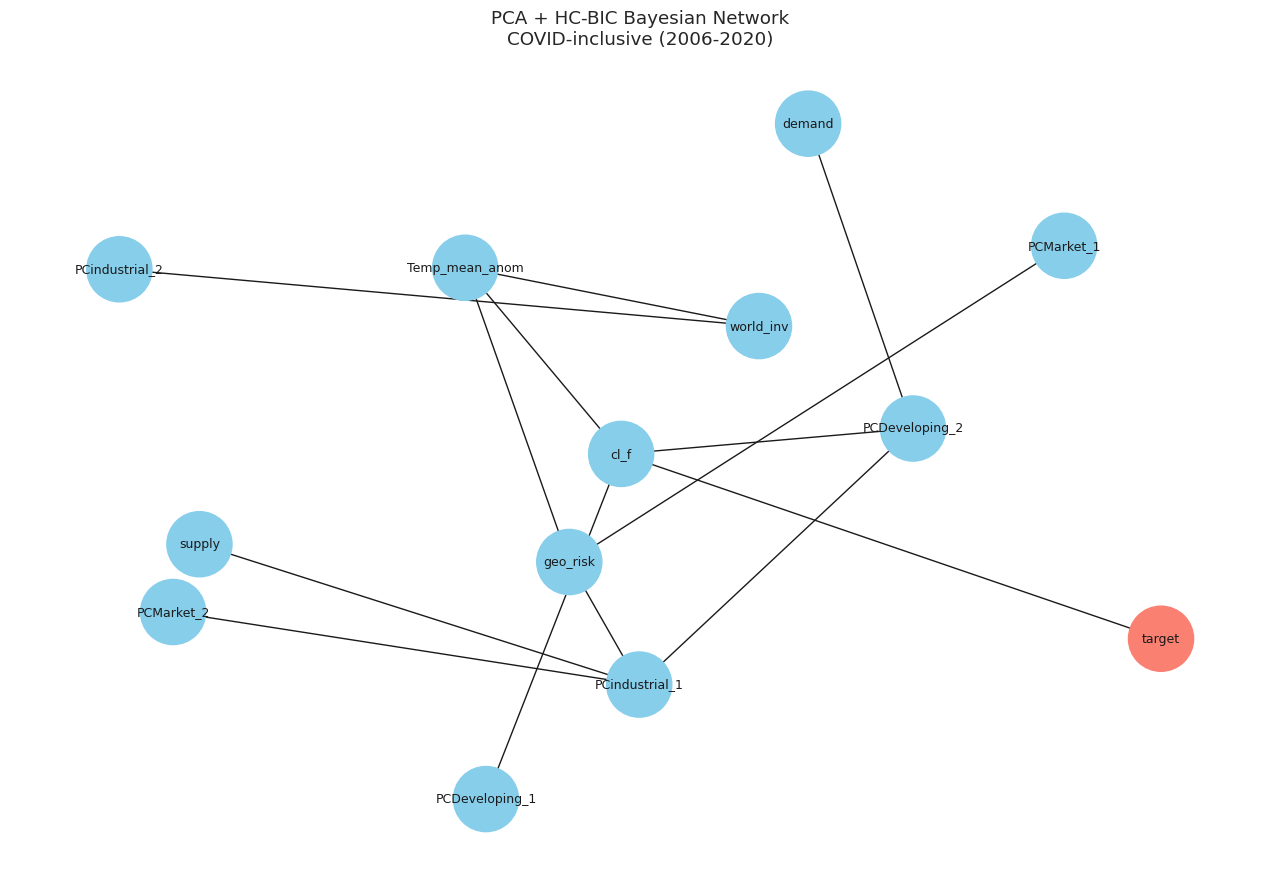

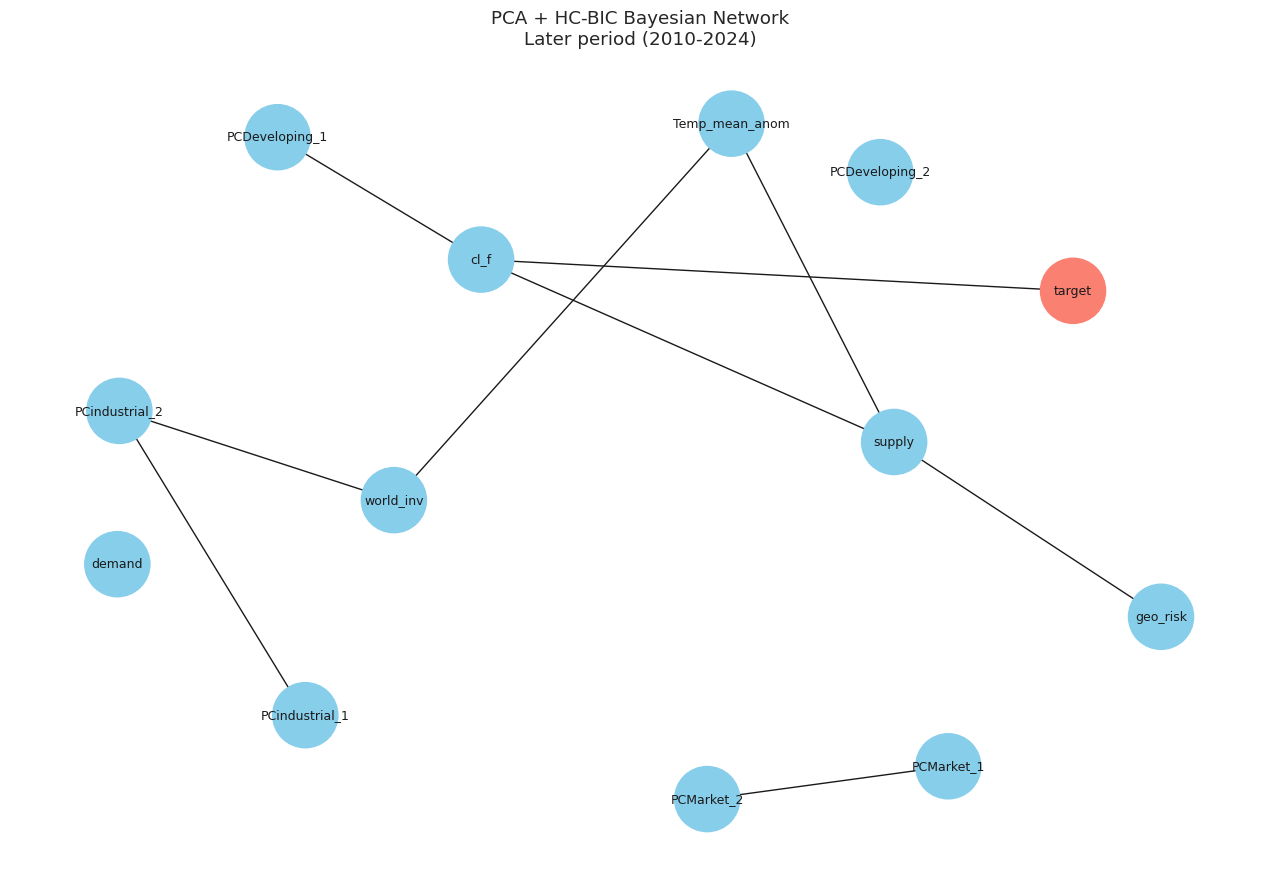

In [ ]:
from scipy.stats import multivariate_normal
# ============================================================
# EVENT-BASED BAYESIAN NETWORK ANALYSIS
# PCA + HMM + HC-BIC
# Compare: Pre-COVID, COVID-inclusive, Later period
# ============================================================
# 1. DEFINE THREE 15-YEAR PERIODS
pre_covid_data = df.loc['2004-01-01':'2018-12-31', :].copy()
covid_data = df.loc['2006-01-01':'2020-12-31', :].copy()
after_covid_data = df.loc['2010-01-01':'2024-12-31', :].copy()

periods = {'Pre-COVID (2004-2018)': pre_covid_data,'COVID-inclusive (2006-2020)': covid_data,'Later period (2010-2024)': after_covid_data}

# 2. PCA GROUPS
columns_industrial = ['oecd_inds', 'us_inds', 'IPG21112S', 'A24STI', 'CAPUTLG211S']
columns_developing = ['china_inds', 'russia_inds', 'india_inds']
columns_market = ['vix', 'DX_Y_NYB', 'nasdaq', 'dgs10']

def pca_train(train, columns, column_name, n_components=2):
    """Fit PCA to one group of variables and return scores + diagnostics."""
    sub_train_scaled = train.loc[:, columns]
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(sub_train_scaled)
    x_pca_df = pd.DataFrame(X_pca,columns=[f'PC{column_name}_{i+1}' for i in range(n_components)],index=sub_train_scaled.index,)
    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)
    loadings = pd.DataFrame(pca.components_.T,index=sub_train_scaled.columns,columns=[f'PC{i+1}' for i in range(n_components)],)
    return x_pca_df, loadings, explained, cumulative


def pca_network(data):
    """Scale one period, create the PCA variables, and remove original grouped variables."""
    scaler = QuantileTransformer(n_quantiles=min(100, len(data)),output_distribution='normal',random_state=42,)
    scaled = scaler.fit_transform(data)
    train_df = pd.DataFrame(scaled,index=data.index,columns=data.columns,)
    x_pca_ind, loadings_ind, explained_ind, cumulative_ind = pca_train(train_df, columns_industrial, 'industrial', 2)
    x_pca_devel, loadings_devel, explained_devel, cumulative_devel = pca_train(train_df, columns_developing, 'Developing', 2)
    x_pca_market, loadings_market, explained_market, cumulative_market = pca_train(train_df, columns_market, 'Market', 2)
    train_processed = pd.concat([train_df, x_pca_ind, x_pca_devel, x_pca_market],axis=1,)
    # Remove the original variables represented by PCA components.
    columns_to_drop = columns_industrial + columns_developing + columns_market
    train_processed = train_processed.drop(columns=columns_to_drop)
    pca_information = {'industrial_loadings': loadings_ind,'developing_loadings': loadings_devel,'market_loadings': loadings_market,
        'industrial_explained': explained_ind,'developing_explained': explained_devel,'market_explained': explained_market,
        'industrial_cumulative': cumulative_ind,'developing_cumulative': cumulative_devel,'market_cumulative': cumulative_market,}
    return train_processed, pca_information

# 3. HMM REGIMES
def regime_data(train_processed):
    """Fit a 3-state HMM separately to every variable and label states Low/Middle/High."""

    regime_train_int = pd.DataFrame(index=train_processed.index)
    regime_train_cat = pd.DataFrame(index=train_processed.index)

    for col in train_processed.columns:
        X_train = train_processed[[col]].values
        hmm_model = GaussianHMM(n_components=3,covariance_type='full',n_iter=1000,random_state=42,)
        hmm_model.fit(X_train)
        train_states, train_probs, last_alpha = filter_gaussian_hmm(hmm_model, X_train)
        regime_train_int[col] = train_states
        temp = pd.DataFrame({'value': train_processed[col],'state': train_states,},index=train_processed.index,)
        state_mean = temp.groupby('state')['value'].mean()
        high_state = state_mean.idxmax()
        low_state = state_mean.idxmin()
        mapping = {}
        for state in state_mean.index:
            if state == high_state:
                mapping[state] = 'High'
            elif state == low_state:
                mapping[state] = 'Low'
            else:
                mapping[state] = 'Middle'
        regime_train_cat[col] = regime_train_int[col].map(mapping)
    return regime_train_int, regime_train_cat

# 4. LEARN ONE PCA + HC-BIC NETWORK FOR EACH PERIOD
period_results = {}
for period_name, period_data in periods.items():
    print('\n' + '=' * 90)
    print(period_name)
    print('=' * 90)
    # PCA preprocessing
    processed_data, pca_info = pca_network(period_data)
    # HMM regime detection
    regime_int, regime_cat = regime_data(processed_data)

    # Remove constant variables, if any
    constant_cols = [col for col in regime_cat.columns if regime_cat[col].nunique() <= 1]
    train = regime_cat.drop(columns=constant_cols).copy()
    # Create next-month crude-oil regime target
    train['target'] = train['cl_f'].shift(-1)
    train = train.dropna().copy()
    # Learn the selected Bayesian Network: HC-BIC
    model = build_bn(train,HillClimbSearch, BIC,max_indegree=4,)
    edges = list(model.edges())
    target_parents = list(model.get_parents('target'))
    cl_f_parents = list(model.get_parents('cl_f'))
    cl_f_children = list(model.get_children('cl_f'))

    period_results[period_name] = {'model': model,'data': train,'edges': edges,
        'target_parents': target_parents,'cl_f_parents': cl_f_parents,'cl_f_children': cl_f_children,
        'constant_cols': constant_cols,'pca_info': pca_info,}

    print(f'Observations used: {len(train)}')
    print(f'Number of edges: {len(edges)}')
    print(f'Target parents: {target_parents}')
    print(f'cl_f parents: {cl_f_parents}')
    print(f'cl_f children: {cl_f_children}')

    if constant_cols:
        print(f'Removed constant variables: {constant_cols}')

    variables = []
    print('\nEdges:')
    for parent, child in edges:
        print(f'  {parent} -> {child}')
        variables.append(parent)
        variables.append(child)
    variables = list(set(variables))

    print('\n' + '=' * 90)
    print(f'Local Independecies given the parent nodes: {period_name}')
    print('=' * 90)
    print(model.local_independencies(variables))

    print('\n' + '=' * 90)
    print(f'Active trail nodes for each variable: {period_name}')
    print('=' * 90)
    for v in variables:
      print(model.active_trail_nodes(v))

# 5. COMPARE PCA LOADINGS ACROSS THE THREE PERIODS
for period_name, result in period_results.items():

    print('\n' + '=' * 90)
    print(f'PCA LOADINGS: {period_name}')
    print('=' * 90)

    print('\nMarket PCA loadings')
    display(result['pca_info']['market_loadings'])

    print('\nDeveloping-country PCA loadings')
    display(result['pca_info']['developing_loadings'])

    print('\nIndustrial PCA loadings')
    display(result['pca_info']['industrial_loadings'])

# 6. JACCARD SIMILARITY BETWEEN THE THREE NETWORKS
def edge_jaccard(edges1, edges2):
    e1 = set(edges1)
    e2 = set(edges2)
    union = e1 | e2

    if len(union) == 0:
        return 1.0

    return len(e1 & e2) / len(union)

period_names = list(period_results.keys())

comparisons = [(period_names[0], period_names[1]),(period_names[1], period_names[2]),(period_names[0], period_names[2]),]

print('\n' + '=' * 90)
print('NETWORK STRUCTURAL COMPARISON')
print('=' * 90)

for period_1, period_2 in comparisons:
    similarity = edge_jaccard(period_results[period_1]['edges'],period_results[period_2]['edges'],)
    print(f'{period_1} vs {period_2}: Jaccard = {similarity:.3f}')

# 7. IDENTIFY EDGES THAT APPEAR / DISAPPEAR
for period_1, period_2 in comparisons:
    edges_1 = set(period_results[period_1]['edges'])
    edges_2 = set(period_results[period_2]['edges'])
    appeared = edges_2 - edges_1
    disappeared = edges_1 - edges_2
    persistent = edges_1 & edges_2

    print('\n' + '=' * 90)
    print(f'{period_1}  ->  {period_2}')
    print('=' * 90)

    print('\nPersistent edges:')
    for edge in sorted(persistent):
        print(f'  {edge[0]} -> {edge[1]}')

    print('\nNew edges:')
    for edge in sorted(appeared):
        print(f'  {edge[0]} -> {edge[1]}')

    print('\nDisappeared edges:')
    for edge in sorted(disappeared):
        print(f'  {edge[0]} -> {edge[1]}')


# 8. PLOT THE THREE NETWORKS
for period_name, result in period_results.items():
    model = result['model']
    G = nx.DiGraph()
    G.add_nodes_from(model.nodes())
    G.add_edges_from(model.edges())

    plt.figure(figsize=(13, 9))

    pos = nx.spring_layout(G, seed=42, k=1.2)

    node_colors = ['salmon' if node == 'target' else 'skyblue' for node in G.nodes()]
    nx.draw_networkx_nodes(G,pos,node_size=2200,node_color=node_colors,)
    nx.draw_networkx_edges(G,pos,arrows=True,arrowsize=25,arrowstyle='-|>',)
    nx.draw_networkx_labels(G, pos,font_size=9,)
    plt.title(f'PCA + HC-BIC Bayesian Network\n{period_name}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()